# Feature Exploration — Cross-Sectional Return Prediction

Diagnoses every engineered feature along six axes:

1. **Coverage** — what fraction of observations are non-null?
2. **Distributions** — cross-sectional shape (heavy tails, skew)?
3. **Correlation structure** — which features overlap or are redundant?
4. **Univariate IC** — rank-correlation with 21-day forward return, ICIR, Newey-West t-stat
5. **IC over time** — is predictive power stable or regime-dependent?
6. **Quintile spreads** — is the IC driven by a monotonic relationship or outliers?


In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm

sys.path.insert(0, "../../src")
from utils import _newey_west_tstat

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})
sns.set_style("whitegrid")

# ── Paths ──────────────────────────────────────────────────────────────────
RAW_PATH     = Path("../../data/raw/yahoo_S&P_500/raw.parquet")
FEATURES_DIR = Path("../../data/features/yahoo_S&P_500")
SAVE_DIR     = Path("../../results/feature_exploration")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ── Feature registry ───────────────────────────────────────────────────────
FEATURE_GROUPS = {
    "momentum":       ["mom_1_5", "mom_1_21", "mom_21_126", "mom_21_252", "mom_126_252", "mom_252_756"],
    "volatility":     ["vol_21", "vol_63", "vol_252", "downside_dev_21", "downside_dev_63", "downside_dev_252"],
    "liquidity":      ["dollar_volume_21", "dollar_volume_63"],
    "extreme":        ["dist_252_high", "max_21"],
    "skewness":       ["skew_21", "skew_63", "skew_252"],
    "beta":           ["rolling_beta", "idiosyncratic"],
    "amihud":         ["amihud_21", "amihud_63", "amihud_252"],
    "parkinson_vol":  ["parkinsons_vol_21", "parkinsons_vol_63", "parkinsons_vol_252"],
    "vol_surprise":   ["vol_surprise_21", "vol_surprise_63", "vol_surprise_252"],
    "return_zscore":  ["return_zscore_5", "return_zscore_21", "return_zscore_63", "return_zscore_252"],
    "pv_interaction": ["pv_interaction_21", "pv_interaction_63", "pv_interaction_252"],
    "ivol":           ["ivol_21", "ivol_63", "ivol_252"],
    "price_to_ma":    ["price_to_ma_5", "price_to_ma_20", "price_to_ma_63", "price_to_ma_200"],
    "idio_momentum":  ["idio_mom_21_252", "idio_mom_21_126"],
    "vol_ratio":      ["vol_ratio_5_21", "vol_ratio_10_63", "vol_ratio_21_252"],
}

FEATURE_FILES = {
    "momentum":       "momentum.parquet",
    "volatility":     "volatility.parquet",
    "liquidity":      "liquidity.parquet",
    "extreme":        "extreme.parquet",
    "skewness":       "skewness.parquet",
    "beta":           "beta.parquet",
    "amihud":         "amihud.parquet",
    "parkinson_vol":  "parkinson_vol.parquet",
    "vol_surprise":   "volume_surprise.parquet",
    "return_zscore":  "return_zscore.parquet",
    "pv_interaction": "pv_interaction.parquet",
    "ivol":           "ivol.parquet",
    "price_to_ma":    "price_to_ma.parquet",
    "idio_momentum":  "idio_momentum.parquet",
    "vol_ratio":      "vol_ratio.parquet",
}
ALL_FEATURES  = [f for flist in FEATURE_GROUPS.values() for f in flist]
FEAT_TO_GROUP = {f: g for g, flist in FEATURE_GROUPS.items() for f in flist}

_palette = sns.color_palette("tab20", n_colors=len(FEATURE_GROUPS))
GROUP_COLORS = {g: _palette[i] for i, g in enumerate(FEATURE_GROUPS)}

print(f"Total features: {len(ALL_FEATURES)}")
for g, fs in FEATURE_GROUPS.items():
    print(f"  {g:20s} ({len(fs):2d}):  {', '.join(fs)}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Total features: 49
  momentum             ( 6):  mom_1_5, mom_1_21, mom_21_126, mom_21_252, mom_126_252, mom_252_756
  volatility           ( 6):  vol_21, vol_63, vol_252, downside_dev_21, downside_dev_63, downside_dev_252
  liquidity            ( 2):  dollar_volume_21, dollar_volume_63
  extreme              ( 2):  dist_252_high, max_21
  skewness             ( 3):  skew_21, skew_63, skew_252
  beta                 ( 2):  rolling_beta, idiosyncratic
  amihud               ( 3):  amihud_21, amihud_63, amihud_252
  parkinson_vol        ( 3):  parkinsons_vol_21, parkinsons_vol_63, parkinsons_vol_252
  vol_surprise         ( 3):  vol_surprise_21, vol_surprise_63, vol_surprise_252
  return_zscore        ( 4):  return_zscore_5, return_zscore_21, return_zscore_63, return_zscore_252
  pv_interaction       ( 3):  pv_interaction_21, pv_interaction_63, pv_interaction_252
  ivol                 ( 3):  ivol_21,

---
## 1. Data Loading

In [40]:
# Wide parquet → long panel
wide = pd.read_parquet(RAW_PATH)
wide.columns.names = ["field", "Ticker"]
long = wide.stack(level="Ticker", future_stack=True)
long.index.names = ["Date", "Ticker"]

# 21-day forward return (no look-ahead: shift future prices back)
adj = long["Adj Close"].unstack("Ticker").sort_index()
fwd_ret = adj.pct_change(21, fill_method=None).shift(-21)
fwd_ret = fwd_ret.stack(future_stack=True).rename("fwd_ret_21")
fwd_ret.index.names = ["Date", "Ticker"]

# Cross-sectional rank → [0, 1]  (target for IC)
target     = fwd_ret.groupby(level="Date").rank(pct=True).rename("target")
target_df  = pd.concat([target, fwd_ret], axis=1)

n_tick = target_df.index.get_level_values("Ticker").nunique()
n_days = target_df.index.get_level_values("Date").nunique()
d_min  = target_df.index.get_level_values("Date").min().date()
d_max  = target_df.index.get_level_values("Date").max().date()
print(f"Universe : {n_tick} tickers,  {n_days} trading days  ({d_min} → {d_max})")
print(f"Target coverage: {target.notna().mean():.1%}")

Universe : 503 tickers,  6347 trading days  (2001-01-02 → 2026-03-30)
Target coverage: 88.0%


In [41]:
parts = []
for group, fname in FEATURE_FILES.items():
    d = pd.read_parquet(FEATURES_DIR / fname)
    parts.append(d)
    print(f"  {group:20s}: {d.shape}   {list(d.columns)}")

features_df = pd.concat(parts, axis=1)
features_df = features_df.loc[:, ~features_df.columns.duplicated()]
print(f"\nAll features joined: {features_df.shape}")

  momentum            : (2821312, 6)   ['mom_1_5', 'mom_1_21', 'mom_21_126', 'mom_21_252', 'mom_126_252', 'mom_252_756']
  volatility          : (2821312, 6)   ['vol_21', 'vol_63', 'vol_252', 'downside_dev_21', 'downside_dev_63', 'downside_dev_252']
  liquidity           : (2821312, 2)   ['dollar_volume_21', 'dollar_volume_63']
  extreme             : (2821312, 2)   ['dist_252_high', 'max_21']
  skewness            : (2821312, 3)   ['skew_21', 'skew_63', 'skew_252']
  beta                : (2821312, 2)   ['rolling_beta', 'idiosyncratic']
  amihud              : (2821312, 3)   ['amihud_21', 'amihud_63', 'amihud_252']
  parkinson_vol       : (2821312, 3)   ['parkinsons_vol_21', 'parkinsons_vol_63', 'parkinsons_vol_252']
  vol_surprise        : (2821312, 3)   ['vol_surprise_21', 'vol_surprise_63', 'vol_surprise_252']
  return_zscore       : (2821312, 4)   ['return_zscore_5', 'return_zscore_21', 'return_zscore_63', 'return_zscore_252']
  pv_interaction      : (2821312, 3)   ['pv_interactio

In [42]:
panel = features_df.join(target_df, how="left").sort_index()

# Only rows where we can evaluate IC (target is non-null)
panel_ic = panel.dropna(subset=["target"])

# Non-overlapping monthly sample (every 21 trading days) for IC computation
all_dates    = panel_ic.index.get_level_values("Date").unique().sort_values()
sample_dates = all_dates[::21]
panel_sampled = panel_ic.loc[panel_ic.index.get_level_values("Date").isin(sample_dates)]

print(f"Full panel      : {panel.shape[0]:>10,} rows × {panel.shape[1]} cols")
print(f"w/ target       : {panel_ic.shape[0]:>10,} rows")
print(f"Sampled (21d)   : {panel_sampled.shape[0]:>10,} rows  ({len(sample_dates)} cross-sections)")

Full panel      :  2,821,312 rows × 51 cols
w/ target       :  2,810,748 rows
Sampled (21d)   :    134,152 rows  (302 cross-sections)


In [49]:
dates = panel_ic.reset_index().set_index('Date')

In [61]:
dates = dates.index.unique()

In [69]:
dates[0] + pd.DateOffset(months=-1)

Timestamp('2000-12-02 00:00:00')

In [ ]:
fold_starts = range(dates[0], len(dates), 5)

TypeError: 'Timestamp' object cannot be interpreted as an integer

---
## 2. Coverage & Missingness

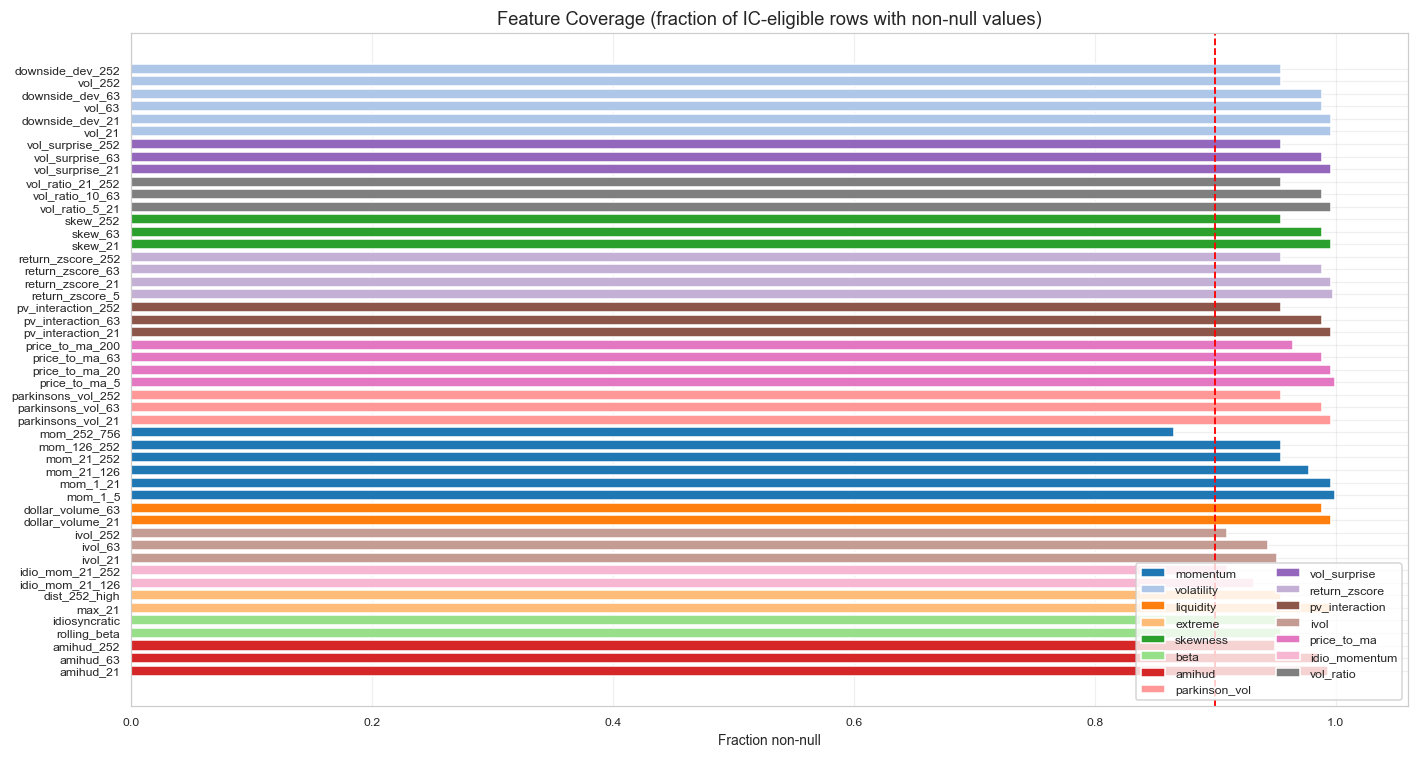


--- Coverage by feature ---
                             group  coverage
amihud_21                   amihud  0.993210
amihud_63                   amihud  0.984917
amihud_252                  amihud  0.949366
rolling_beta                  beta  0.954784
idiosyncratic                 beta  0.954784
max_21                     extreme  0.996063
dist_252_high              extreme  0.954963
idio_mom_21_126      idio_momentum  0.932501
idio_mom_21_252      idio_momentum  0.910057
ivol_21                       ivol  0.951038
ivol_63                       ivol  0.943552
ivol_252                      ivol  0.909880
dollar_volume_21         liquidity  0.996242
dollar_volume_63         liquidity  0.988726
mom_1_5                   momentum  0.999105
mom_1_21                  momentum  0.996242
mom_21_126                momentum  0.977466
mom_21_252                momentum  0.954963
mom_126_252               momentum  0.954963
mom_252_756               momentum  0.865391
parkinsons_vol_21    parki

In [5]:
coverage = panel_ic[ALL_FEATURES].notna().mean().rename("coverage")
cov_df = pd.DataFrame({
    "coverage": coverage,
    "group":    coverage.index.map(FEAT_TO_GROUP),
}).sort_values(["group", "coverage"], ascending=[True, False])

# ── Bar chart ──
fig, ax = plt.subplots(figsize=(13, 7))
bar_colors = [GROUP_COLORS[FEAT_TO_GROUP[f]] for f in cov_df.index]
ax.barh(cov_df.index, cov_df["coverage"], color=bar_colors)
ax.axvline(0.9, color="red", ls="--", lw=1.2, label="90% threshold")
ax.set_xlim(0, 1.06)
ax.set_xlabel("Fraction non-null")
ax.set_title("Feature Coverage (fraction of IC-eligible rows with non-null values)")
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=GROUP_COLORS[g], label=g) for g in FEATURE_GROUPS]
ax.legend(handles=legend_handles, fontsize=8, ncol=2, loc="lower right")
plt.tight_layout()
plt.savefig(SAVE_DIR / "coverage.png", dpi=130, bbox_inches="tight")
plt.show()

print("\n--- Coverage by feature ---")
print(cov_df[["group", "coverage"]].to_string())

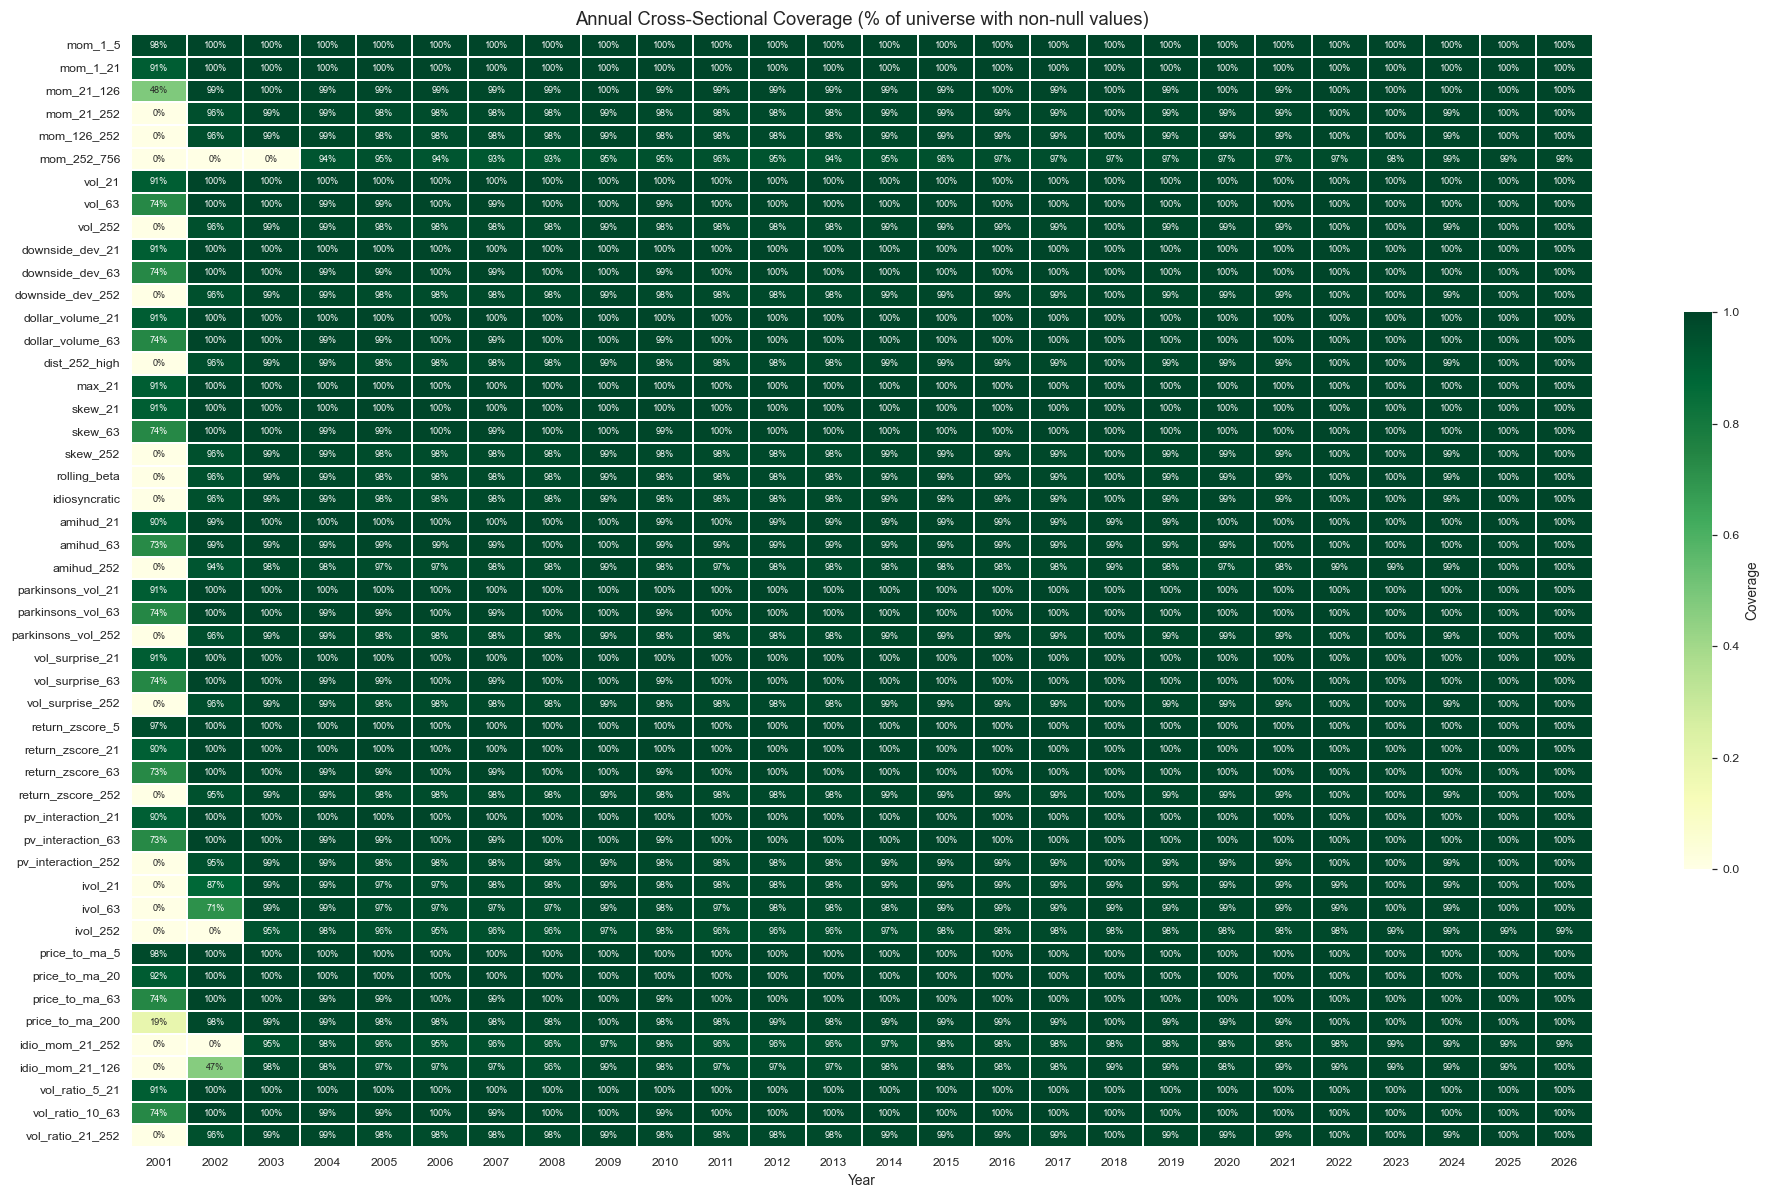

In [6]:
# ── Coverage over time: annual mean (% of universe with non-null) ──────────
daily_cov  = panel_ic[ALL_FEATURES].notna().groupby(level="Date").mean()
annual_cov = daily_cov.groupby(daily_cov.index.year).mean().T

# Order by group
ordered = [f for g in FEATURE_GROUPS for f in FEATURE_GROUPS[g] if f in annual_cov.index]
annual_cov = annual_cov.loc[ordered]

fig, ax = plt.subplots(figsize=(18, 11))
sns.heatmap(
    annual_cov, ax=ax, cmap="YlGn", vmin=0, vmax=1,
    linewidths=0.3, linecolor="white",
    annot=True, fmt=".0%", annot_kws={"size": 6},
    cbar_kws={"label": "Coverage", "shrink": 0.5},
)
ax.set_title("Annual Cross-Sectional Coverage (% of universe with non-null values)")
ax.set_xlabel("Year")
plt.tight_layout()
plt.savefig(SAVE_DIR / "coverage_annual_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

---
## 3. Cross-Sectional Distributions

Values are winsorized at the 1st–99th percentile before plotting.
Dollar volume and Amihud features are log-transformed first.


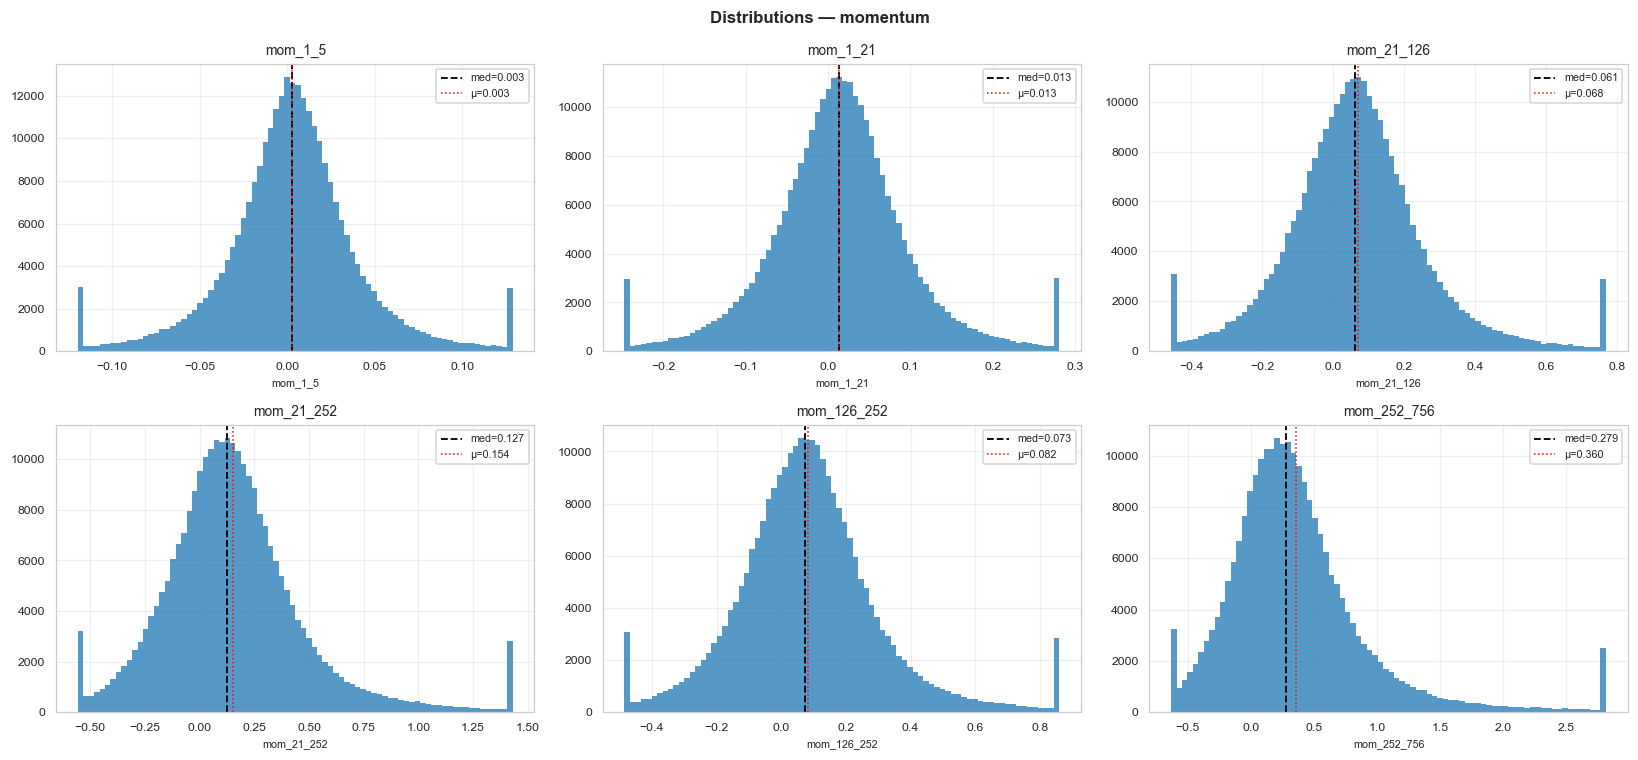

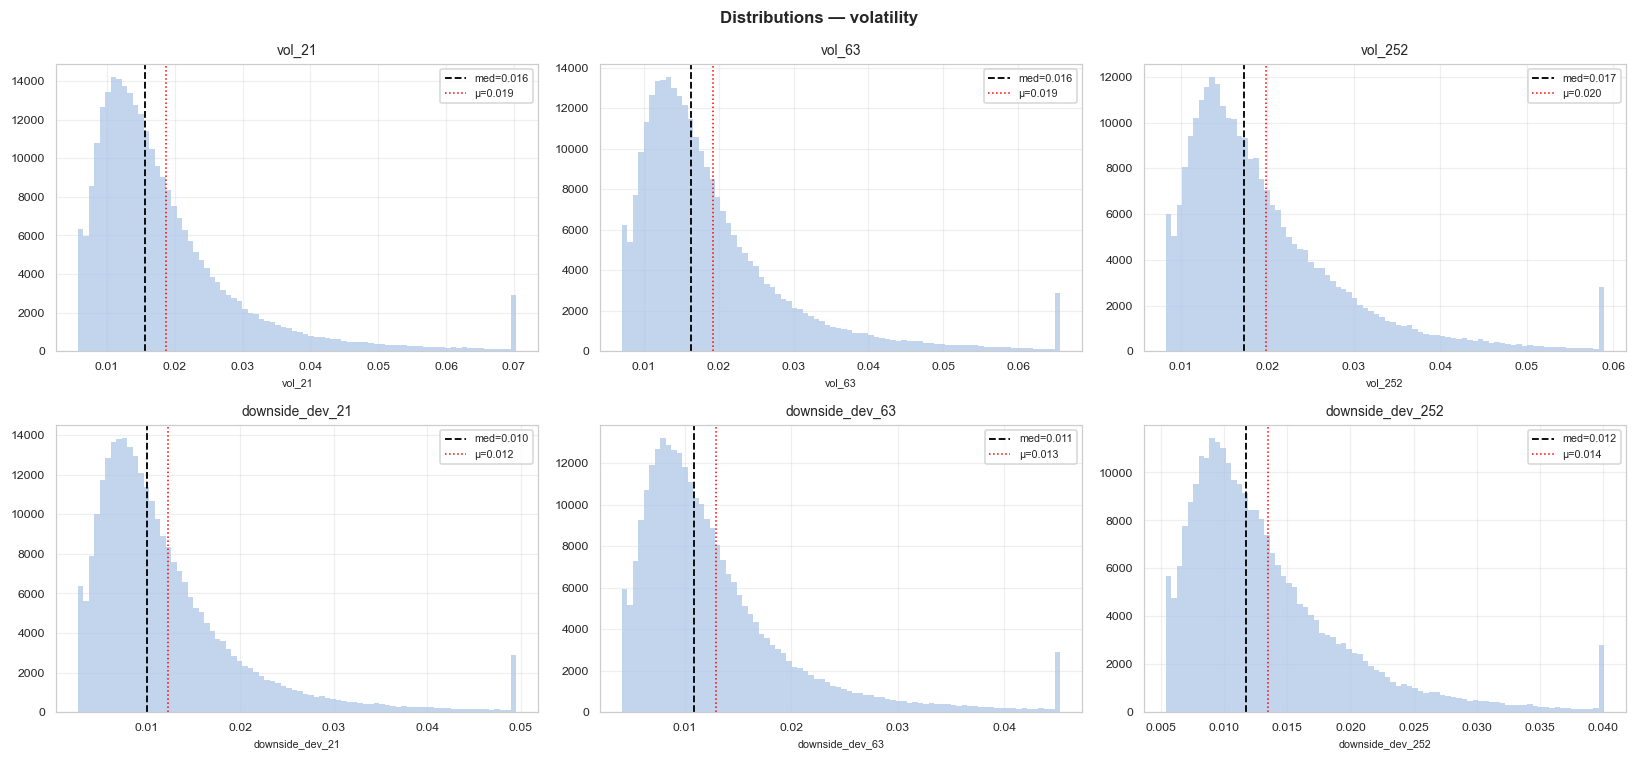

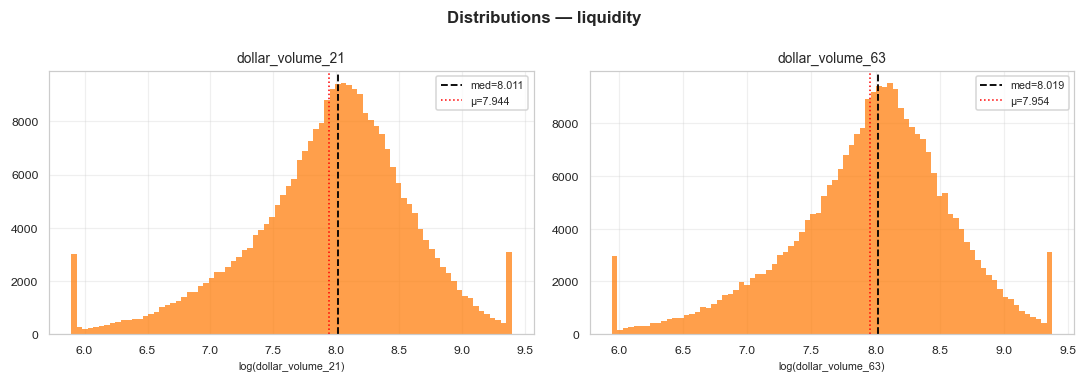

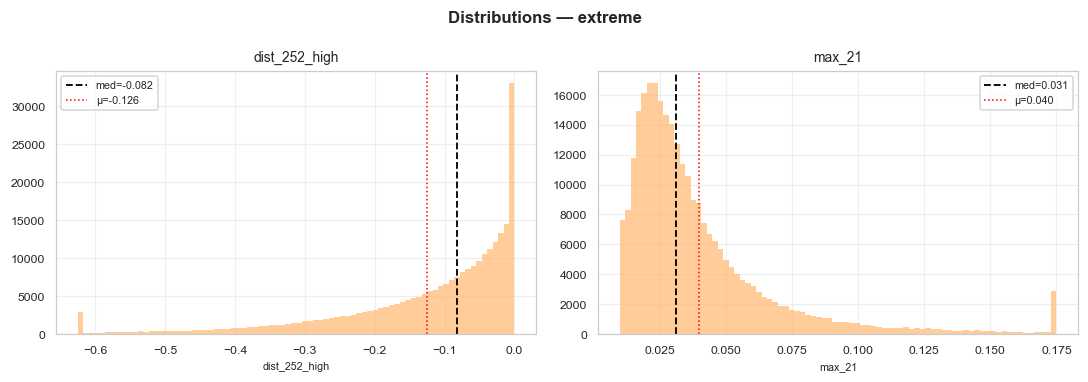

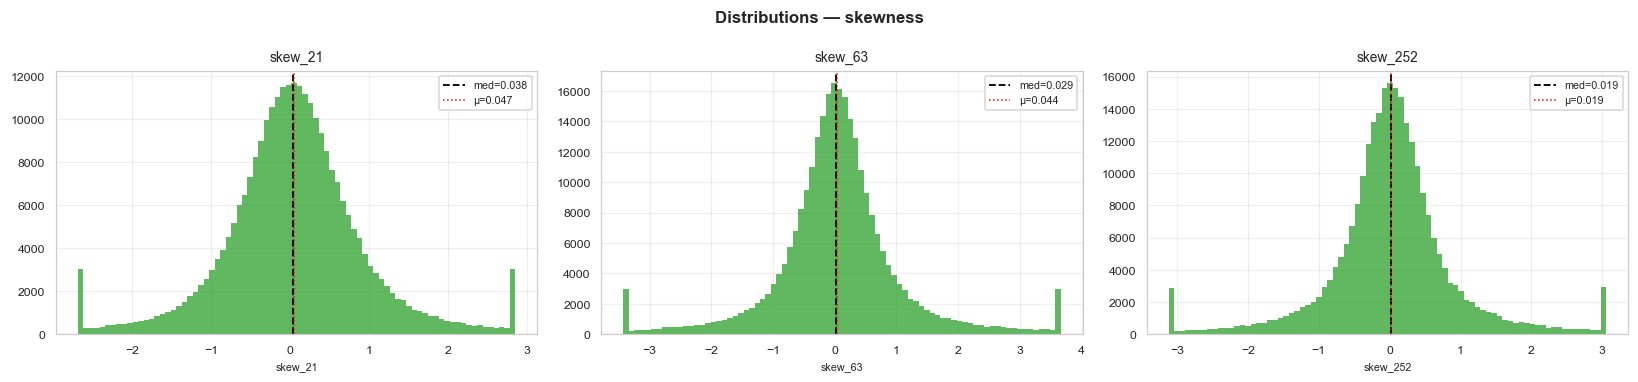

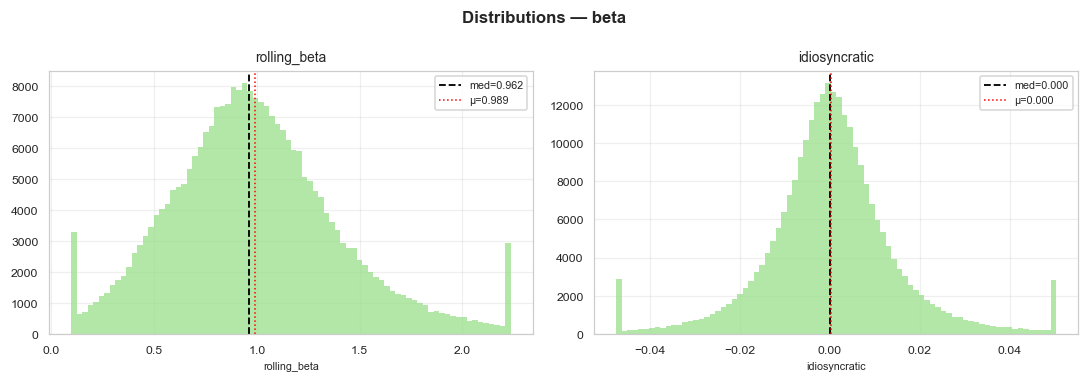

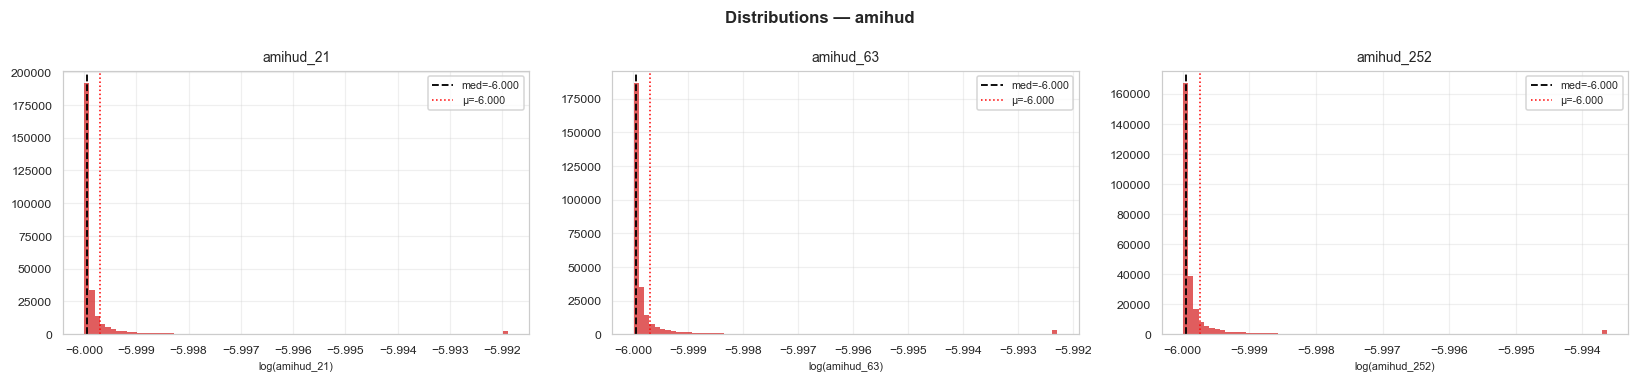

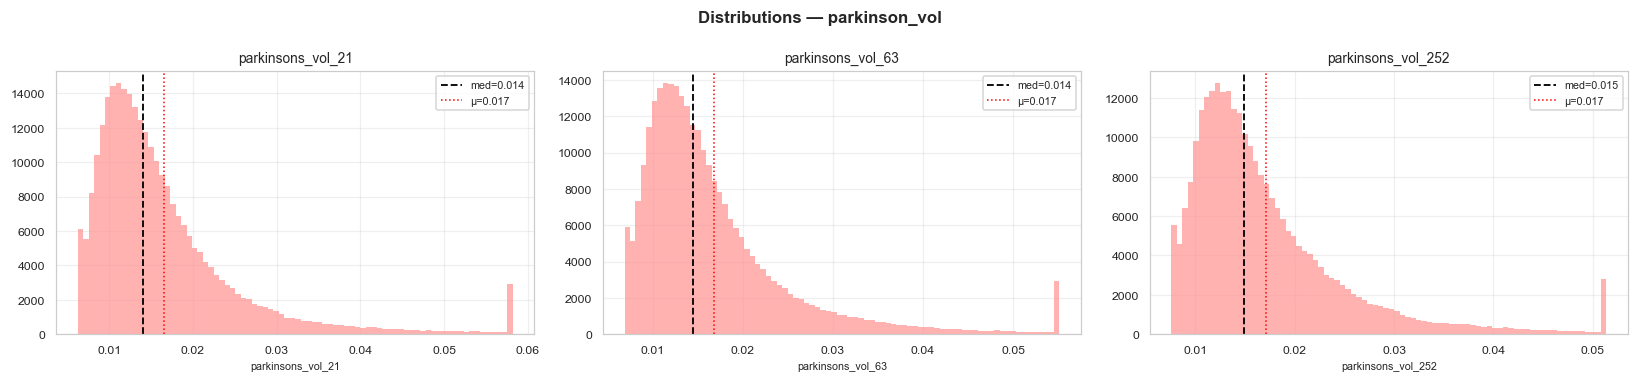

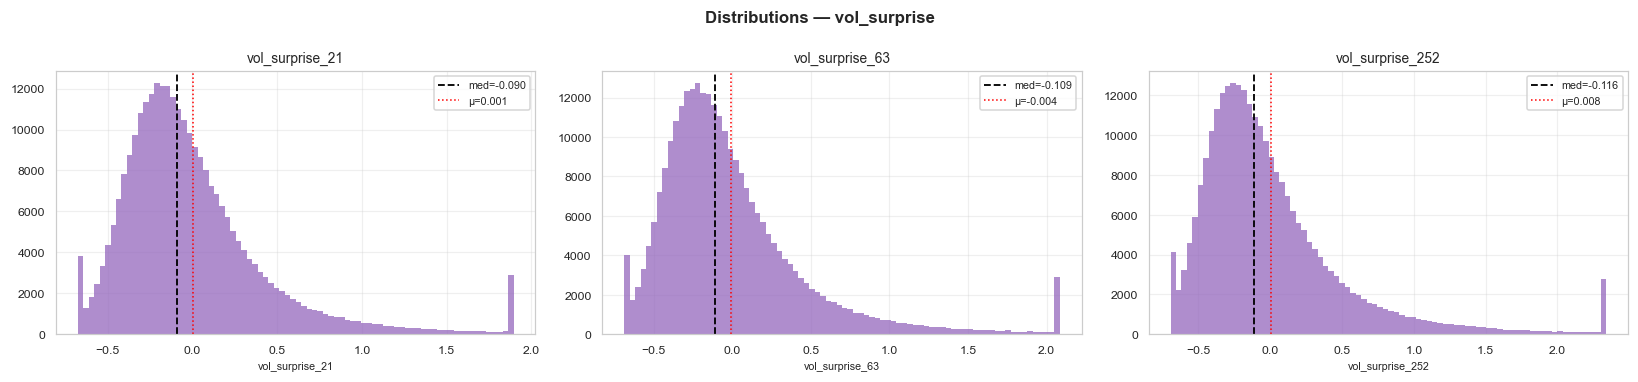

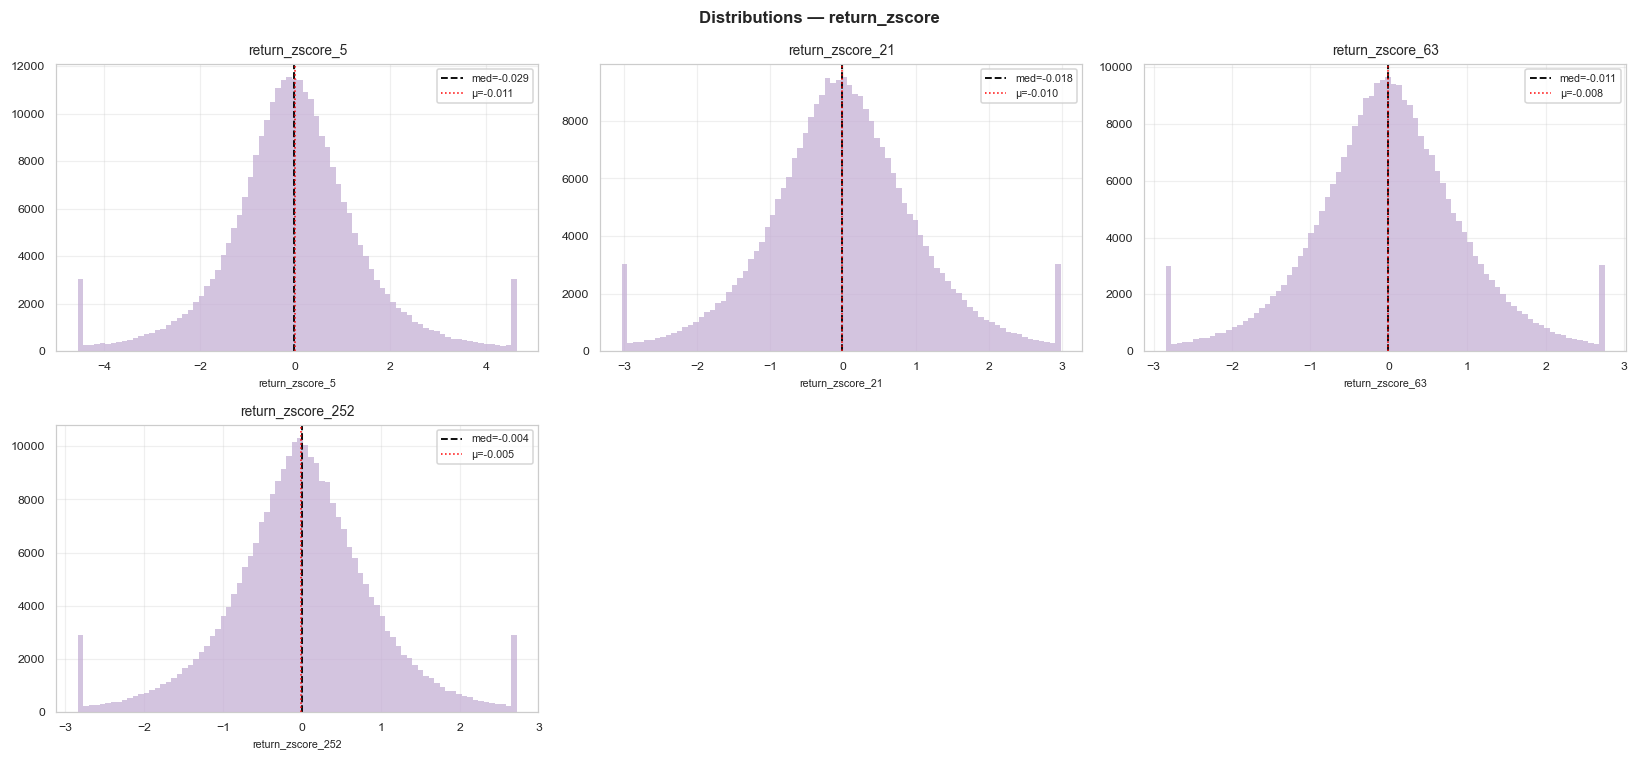

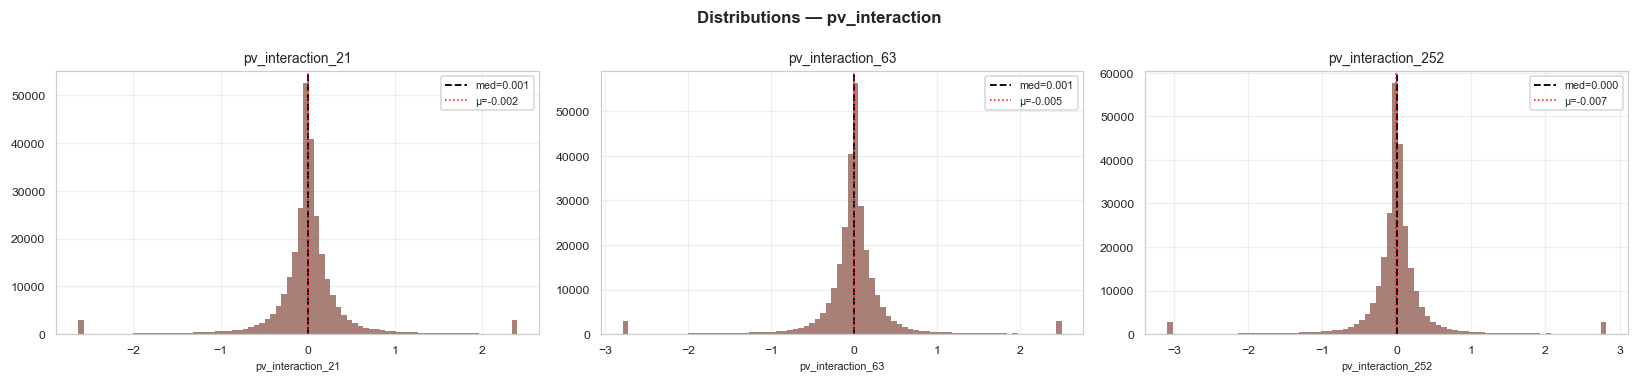

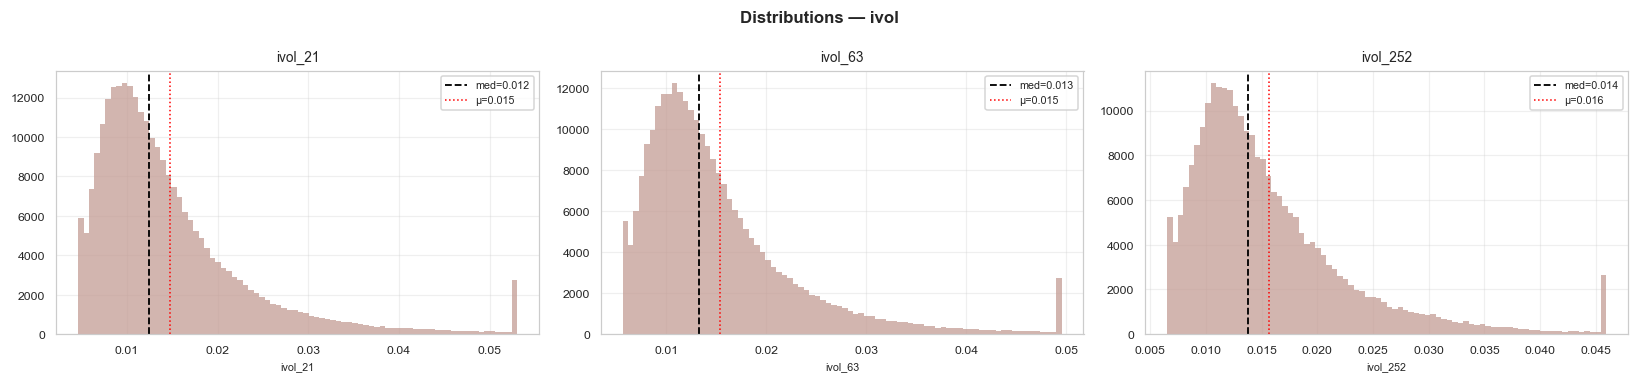

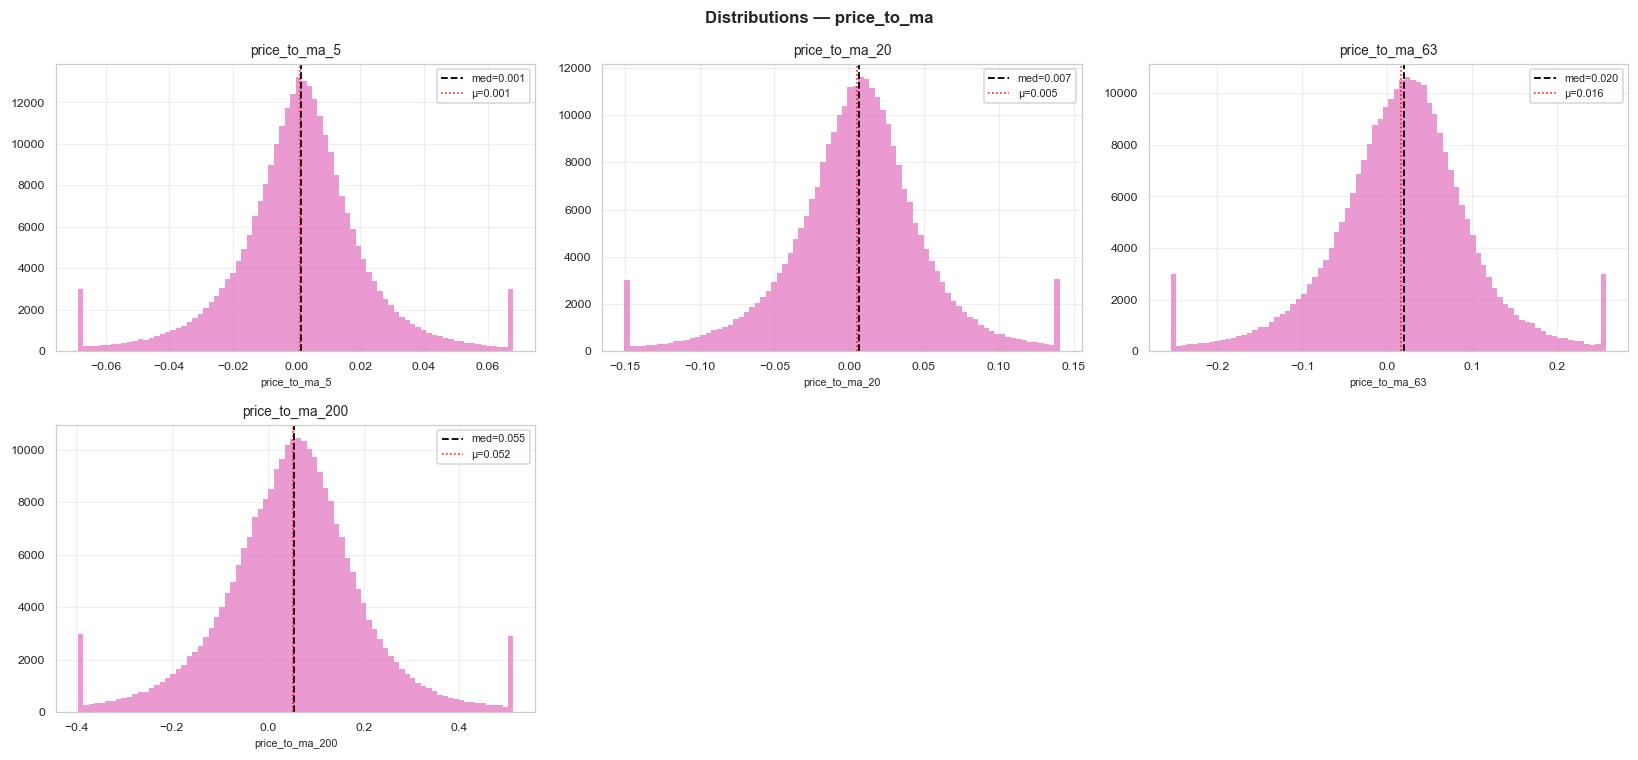

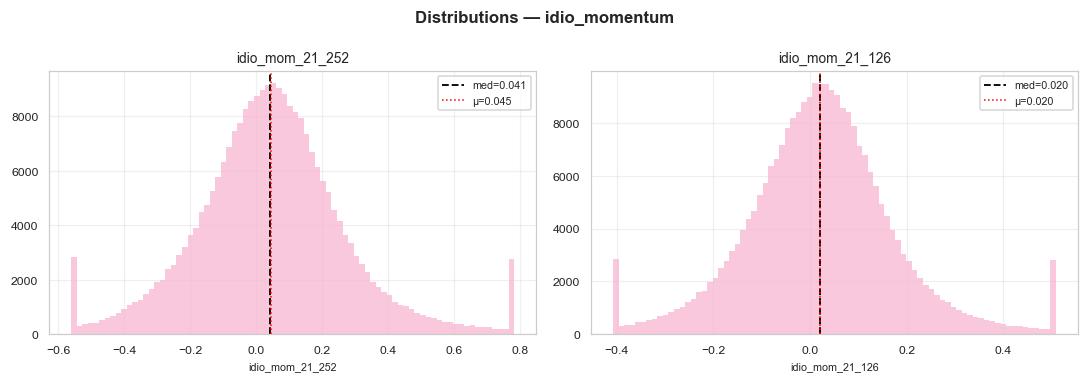

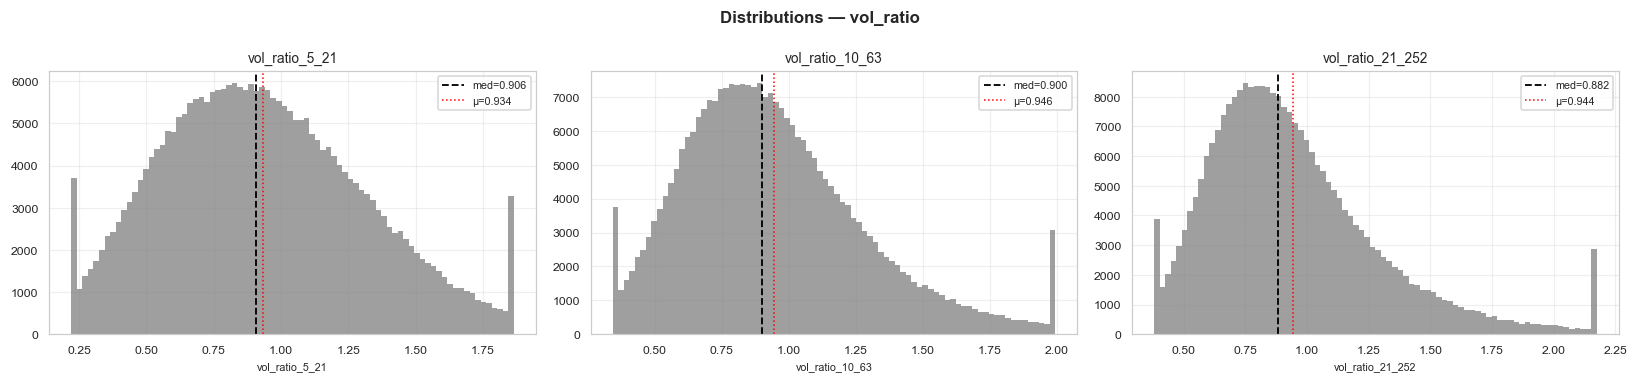

In [8]:
LOG_TRANSFORM_FEATS = {f for g in ["liquidity", "amihud"] for f in FEATURE_GROUPS[g]}
SAMPLE_N = 60_000

def winsorize(s, lo=0.01, hi=0.99):
    lo_v, hi_v = s.quantile([lo, hi])
    return s.clip(lo_v, hi_v)

for group, feats in FEATURE_GROUPS.items():
    ncols = min(3, len(feats))
    nrows = (len(feats) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)
    fig.suptitle(f"Distributions — {group}", fontsize=11, fontweight="bold")

    for idx, feat in enumerate(feats):

        ax = axes[idx // ncols][idx % ncols]
        data = panel_ic[feat].dropna()
        data = data.sample(frac=0.1, random_state=42)
        if feat in LOG_TRANSFORM_FEATS:
            data = data.transform(lambda s: np.log10(s + 1e-6))  # Avoid log(0) or negative
            data = winsorize(data)
            xlabel = f"log({feat})"
        else:
            data = winsorize(data)
            xlabel = feat
        ax.hist(data, bins=80, color=GROUP_COLORS[group], alpha=0.75, edgecolor="none")
        ax.axvline(data.median(), color="black", lw=1.2, ls="--",
                   label=f"med={data.median():.3f}")
        ax.axvline(data.mean(),   color="red",   lw=1.0, ls=":",
                   label=f"μ={data.mean():.3f}")
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel(xlabel, fontsize=7)
        ax.legend(fontsize=7)

    for idx in range(len(feats), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    plt.tight_layout()
    plt.savefig(SAVE_DIR / f"dist_{group}.png", dpi=130, bbox_inches="tight")
    plt.show()

---
## 4. Feature–Feature Correlation

Spearman rank correlation computed on a 100k-row random sample of the panel.
High intra-group correlations suggest redundancy; cross-group correlations reveal
shared information.


Computing Spearman correlation on 100,000 rows × 49 features ...


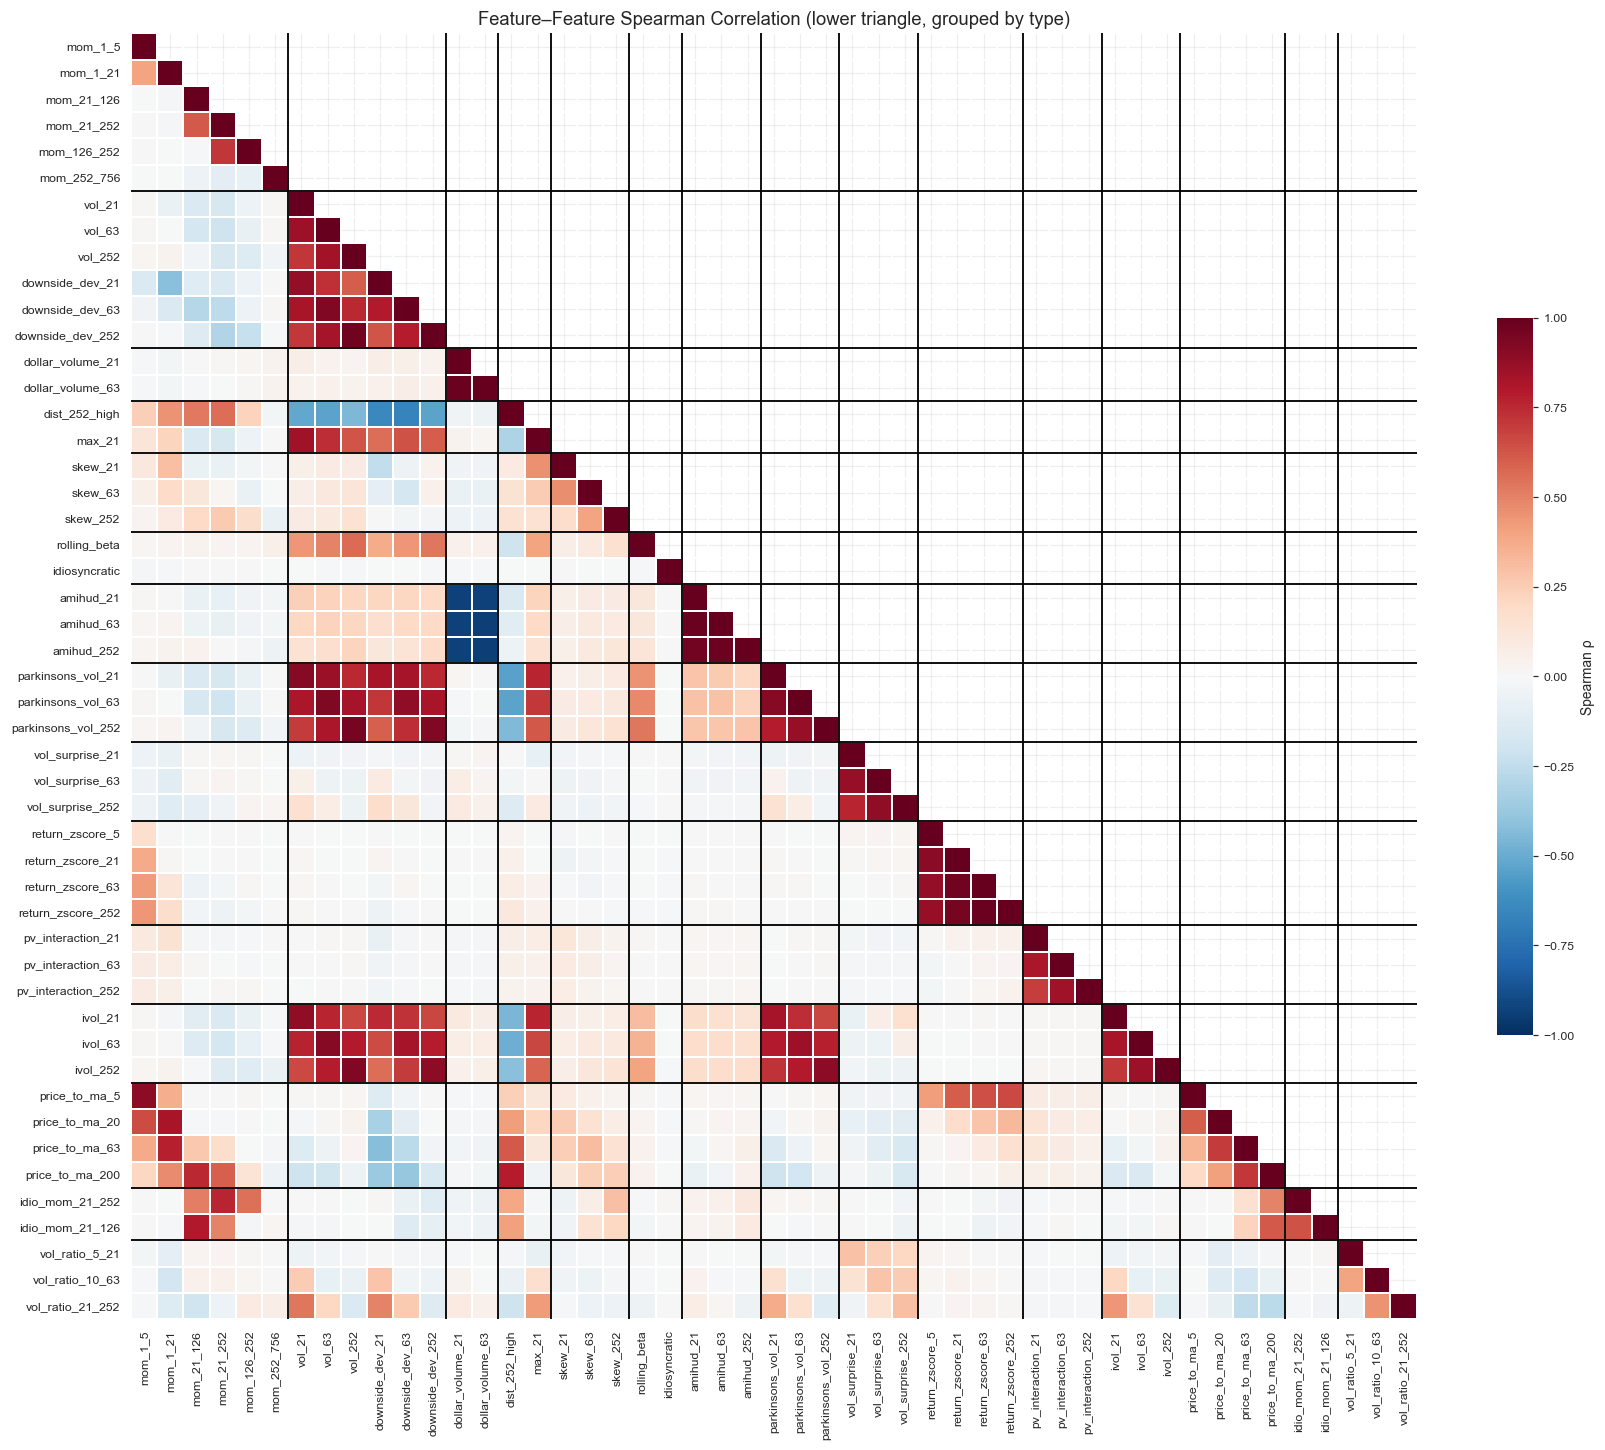


--- Pairs with |ρ| > 0.8 ---
            feat_a             feat_b       rho
  dollar_volume_63   dollar_volume_21  0.989771
         amihud_63          amihud_21  0.987712
 return_zscore_252   return_zscore_63  0.984428
        amihud_252          amihud_63  0.980252
  downside_dev_252            vol_252  0.973564
  return_zscore_63   return_zscore_21  0.972358
        amihud_252          amihud_21  0.964647
 return_zscore_252   return_zscore_21  0.958782
parkinsons_vol_252            vol_252  0.958421
 parkinsons_vol_63             vol_63  0.937168
parkinsons_vol_252   downside_dev_252  0.936762
   downside_dev_63             vol_63  0.929064
          ivol_252            vol_252  0.923611
 parkinsons_vol_21             vol_21  0.913376
           ivol_63             vol_63  0.911224
 parkinsons_vol_63  parkinsons_vol_21  0.910891
  return_zscore_21    return_zscore_5  0.902549
          ivol_252 parkinsons_vol_252  0.894003
          ivol_252   downside_dev_252  0.893544
     price

In [9]:
# Sample for speed
sample_rows = panel_ic[ALL_FEATURES].dropna(how="all")
if len(sample_rows) > 100_000:
    sample_rows = sample_rows.sample(100_000, random_state=42)

print(f"Computing Spearman correlation on {len(sample_rows):,} rows × {len(ALL_FEATURES)} features ...")
corr_mat = sample_rows.corr(method="spearman")

# Reorder by group
ordered = [f for g in FEATURE_GROUPS for f in FEATURE_GROUPS[g]]
corr_mat = corr_mat.loc[ordered, ordered]

# Group boundary positions
group_sizes = [len(FEATURE_GROUPS[g]) for g in FEATURE_GROUPS]
boundaries  = list(np.cumsum(group_sizes)[:-1])

# ── Heatmap (lower triangle) ──
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.zeros_like(corr_mat, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(
    corr_mat, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    mask=mask,
    linewidths=0.15, linecolor="white",
    square=True, annot=False,
    cbar_kws={"label": "Spearman ρ", "shrink": 0.5},
)
for b in boundaries:
    ax.axhline(b, color="black", lw=1.2)
    ax.axvline(b, color="black", lw=1.2)

ax.set_title("Feature–Feature Spearman Correlation (lower triangle, grouped by type)")
plt.tight_layout()
plt.savefig(SAVE_DIR / "feature_correlation_matrix.png", dpi=130, bbox_inches="tight")
plt.show()

# Print highly correlated pairs
print("\n--- Pairs with |ρ| > 0.8 ---")
corr_flat = corr_mat.where(np.tril(np.ones(corr_mat.shape), k=-1).astype(bool))
corr_flat = corr_flat.stack().rename("rho").reset_index()
corr_flat.columns = ["feat_a", "feat_b", "rho"]
high = corr_flat[corr_flat["rho"].abs() > 0.8].sort_values("rho", ascending=False)
print(high.to_string(index=False))

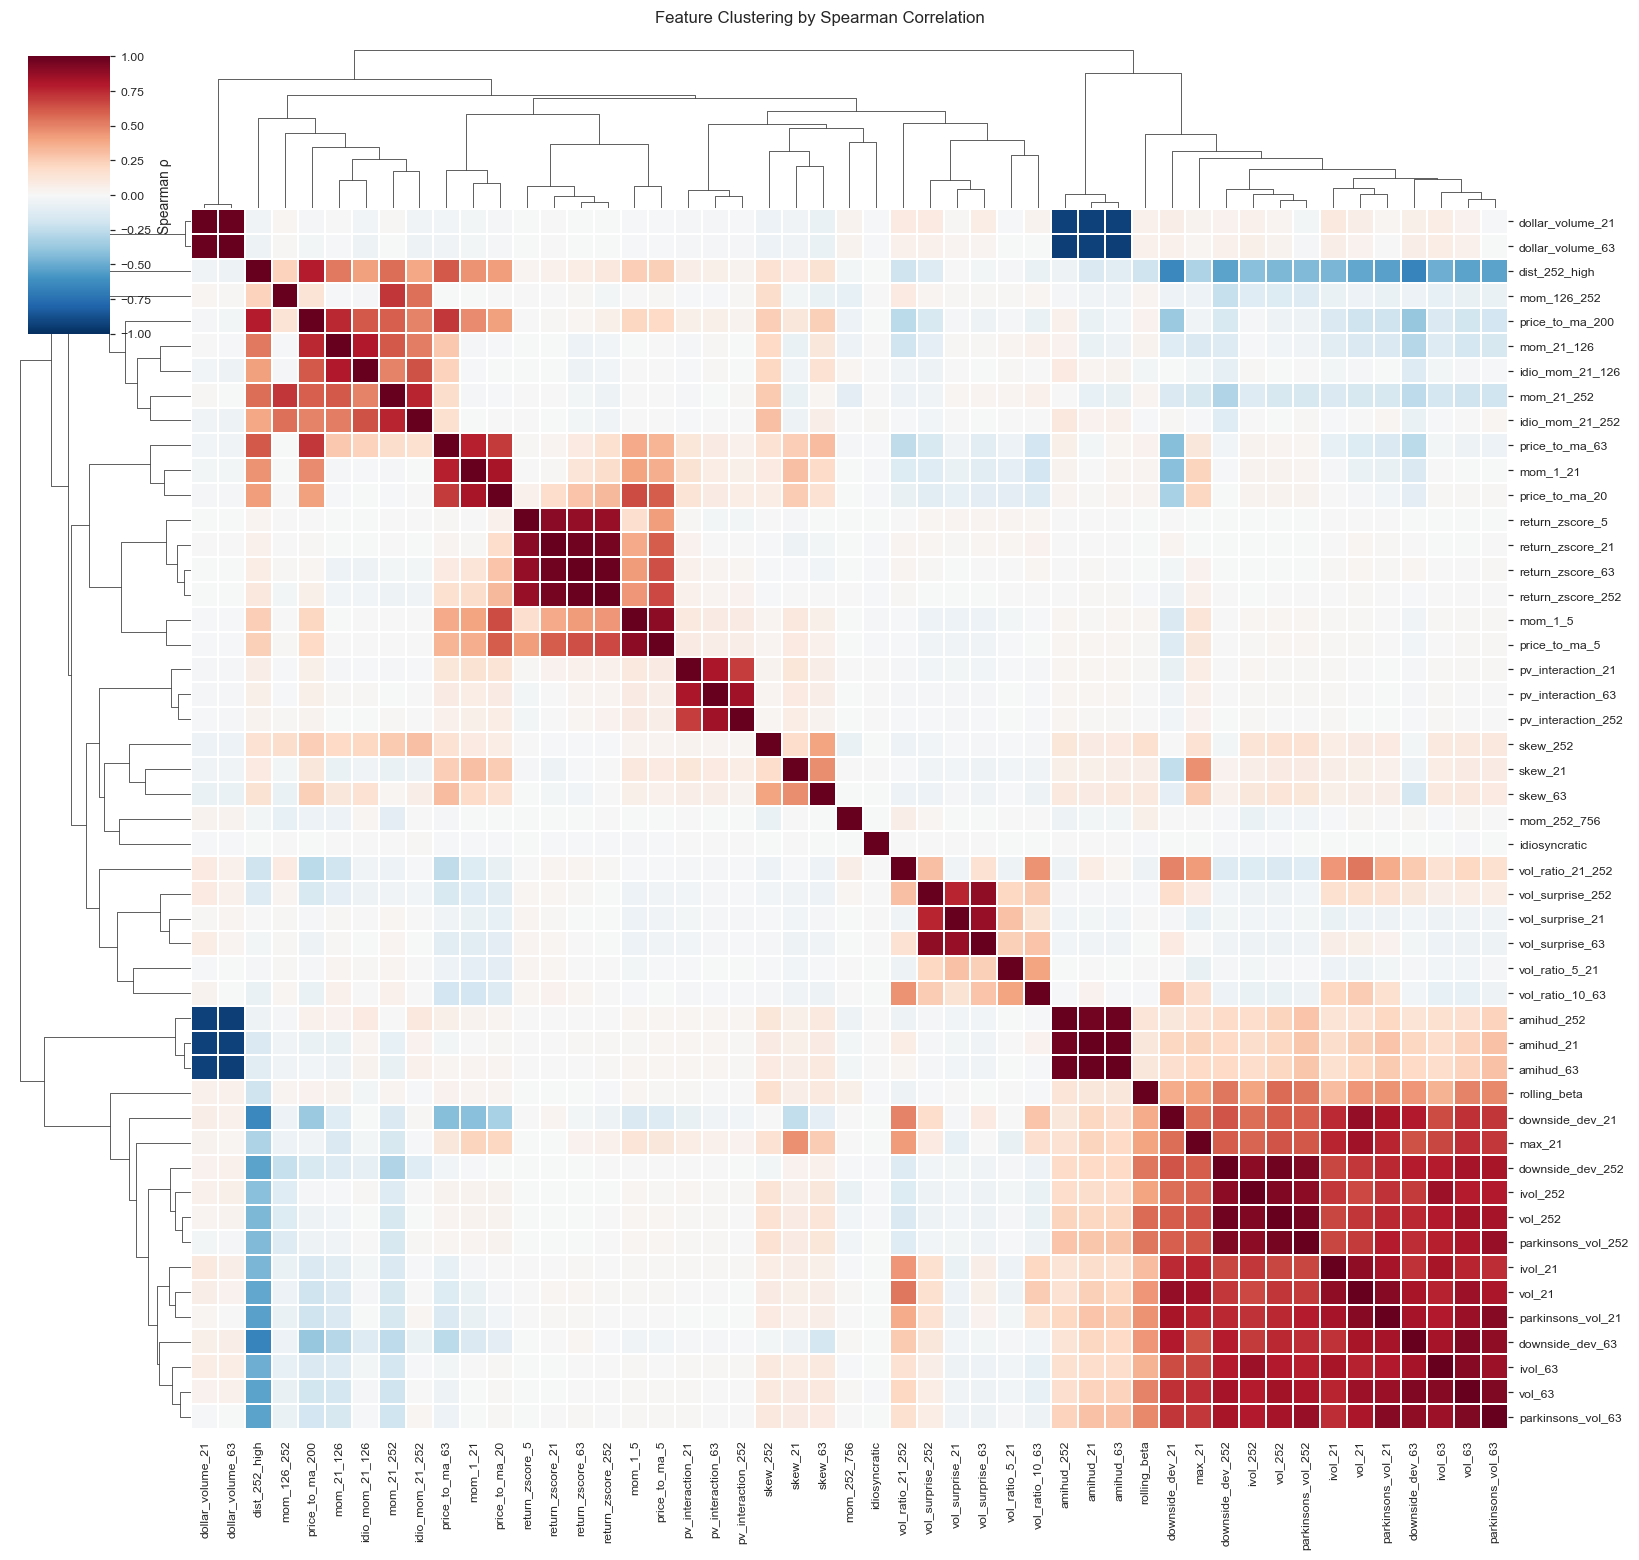

In [10]:
# ── Clustermap ────────────────────────────────────────────────────────────
g = sns.clustermap(
    corr_mat, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    figsize=(15, 14),
    linewidths=0.15, linecolor="white",
    dendrogram_ratio=0.12,
    annot=False,
    cbar_kws={"label": "Spearman ρ", "shrink": 0.4},
)
g.fig.suptitle("Feature Clustering by Spearman Correlation", y=1.01, fontsize=11)
plt.savefig(SAVE_DIR / "feature_clustermap.png", dpi=130, bbox_inches="tight")
plt.show()

---
## 5. Univariate IC Analysis

For each feature we compute the Spearman IC (rank-correlation with the 21-day forward return
rank) on ~300 non-overlapping monthly cross-sections. Summary stats:

- **Mean IC**: average predictive power per cross-section
- **IC Std**: variability over time (lower = more consistent)
- **ICIR = Mean IC / IC Std**: risk-adjusted signal strength
- **NW t-stat**: Newey-West HAC t-statistic for `H₀: mean IC = 0`
- **Hit rate**: fraction of months with positive IC


In [11]:
# Cross-sectionally rank features (Spearman IC = Pearson correlation of CS ranks)
print(f"Ranking {len(ALL_FEATURES)} features across {len(sample_dates)} cross-sections ...")
feat_cs_ranked = (
    panel_sampled[ALL_FEATURES]
    .groupby(level="Date")
    .rank(pct=True)
)
data_ic = feat_cs_ranked.join(panel_sampled["target"])

print("Computing IC (corrwith) ...")
ic_df = (
    data_ic
    .groupby(level="Date")
    .apply(lambda g: g[ALL_FEATURES].corrwith(g["target"]))
)
ic_df.index.name = "Date"
ic_df.index = pd.to_datetime(ic_df.index)

print(f"IC matrix: {ic_df.shape}  ({ic_df.index.min().date()} → {ic_df.index.max().date()})")

Ranking 49 features across 302 cross-sections ...
Computing IC (corrwith) ...
IC matrix: (302, 49)  (2001-01-02 → 2026-02-23)


In [12]:
# ── Summary statistics ──────────────────────────────────────────────────────
def summarise(s):
    s = s.dropna()
    n = len(s)
    if n < 4:
        return pd.Series({"mean_ic": np.nan, "ic_std": np.nan, "icir": np.nan,
                          "nw_tstat": np.nan, "nw_pval": 1.0, "hit_rate": np.nan, "n": n})
    mean_ic  = s.mean()
    ic_std   = s.std()
    icir     = mean_ic / ic_std if ic_std > 0 else np.nan
    nw_t     = _newey_west_tstat(s)
    nw_p     = 2 * (1 - stats.t.cdf(abs(nw_t), n - 1))
    hit_rate = (s > 0).mean()
    return pd.Series({
        "mean_ic":  round(mean_ic,  4),
        "ic_std":   round(ic_std,   4),
        "icir":     round(icir,     3),
        "nw_tstat": round(nw_t,     2),
        "nw_pval":  round(nw_p,     4),
        "hit_rate": round(hit_rate, 3),
        "n":        n,
    })

ic_stats = ic_df.apply(summarise).T
ic_stats["group"] = ic_stats.index.map(FEAT_TO_GROUP)
ic_stats["sig"] = ic_stats["nw_pval"].apply(
    lambda p: "**" if p < 0.01 else ("*" if p < 0.05 else "")
)
ic_stats = ic_stats.sort_values("icir", ascending=False)
ic_stats.to_csv(SAVE_DIR / "ic_summary.csv")

print("=== IC Summary (sorted by ICIR) ===")
print(ic_stats[["group","mean_ic","ic_std","icir","nw_tstat","nw_pval","sig","hit_rate"]].to_string())

=== IC Summary (sorted by ICIR) ===
                             group  mean_ic  ic_std   icir  nw_tstat  nw_pval sig  hit_rate
amihud_21                   amihud   0.0444  0.1073  0.414      8.11   0.0000  **     0.660
amihud_63                   amihud   0.0425  0.1048  0.406      7.95   0.0000  **     0.674
amihud_252                  amihud   0.0410  0.1032  0.397      7.73   0.0000  **     0.664
ivol_252                      ivol   0.0361  0.1995  0.181      3.23   0.0014  **     0.585
parkinsons_vol_63    parkinson_vol   0.0396  0.2410  0.164      3.16   0.0017  **     0.569
ivol_63                       ivol   0.0302  0.1858  0.163      2.94   0.0036  **     0.573
vol_252                 volatility   0.0386  0.2529  0.152      2.76   0.0062  **     0.567
parkinsons_vol_252   parkinson_vol   0.0363  0.2425  0.150      2.73   0.0067  **     0.572
downside_dev_21         volatility   0.0328  0.2189  0.150      2.96   0.0034  **     0.550
downside_dev_63         volatility   0.0353 

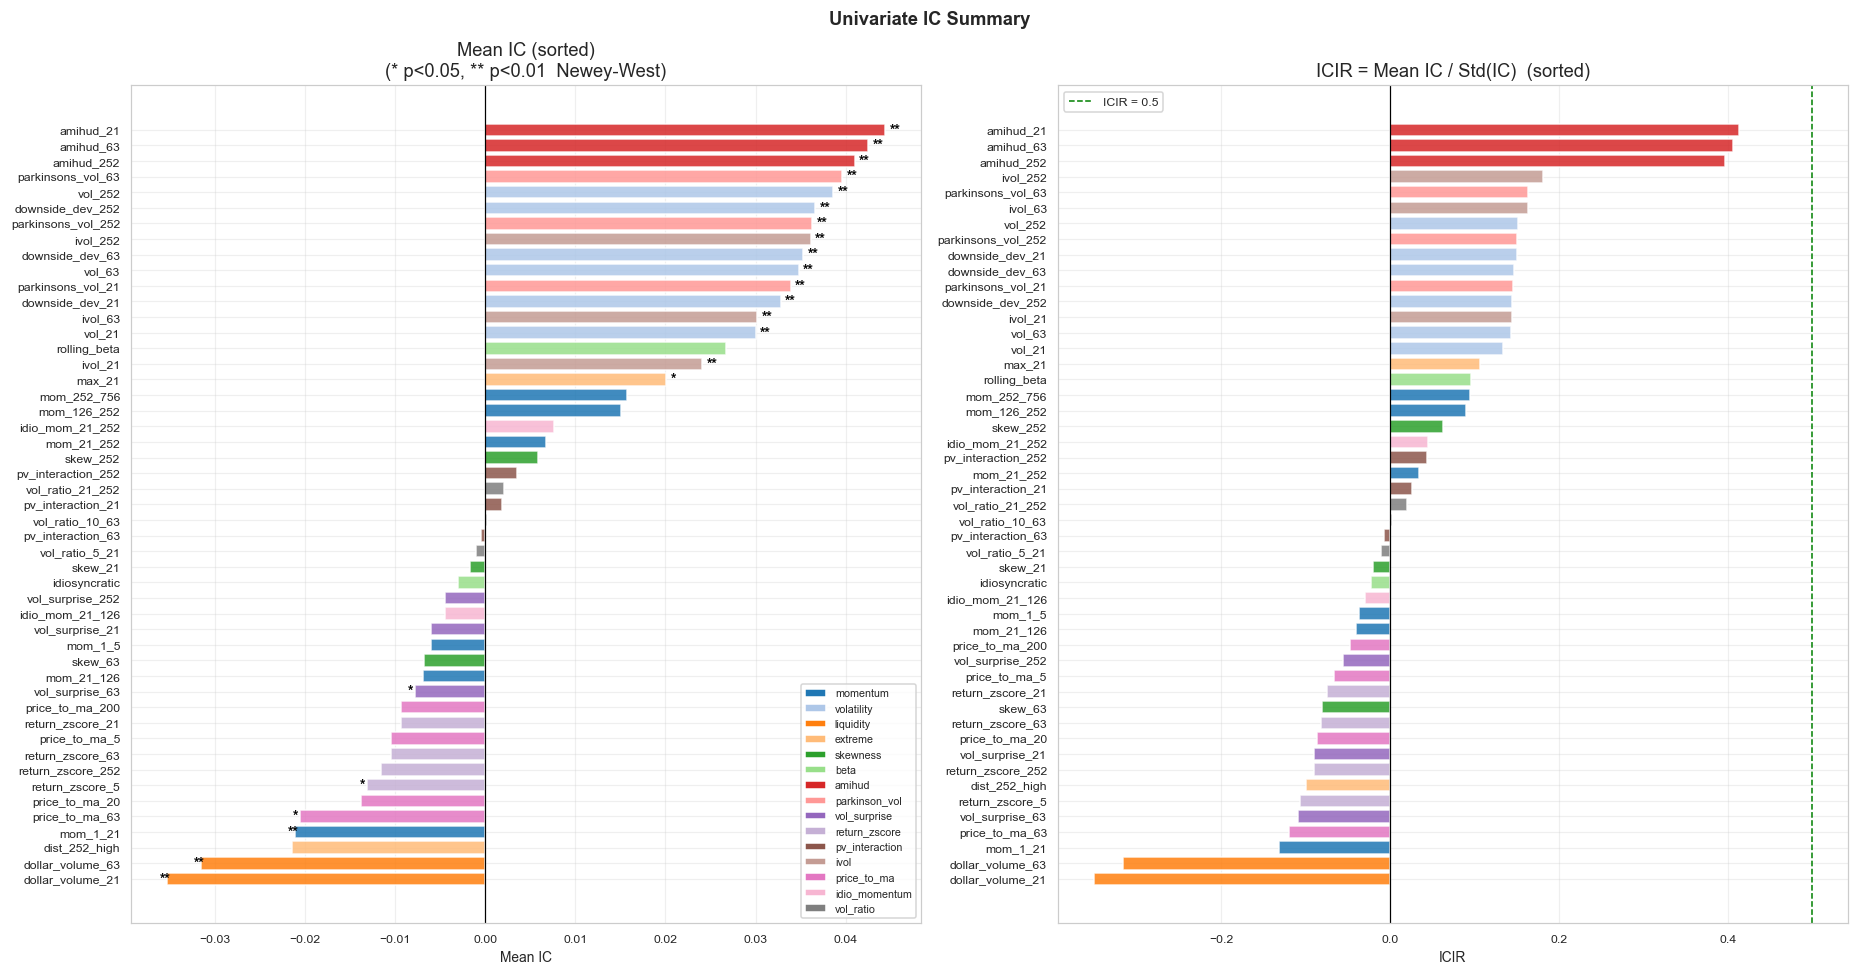

In [14]:
# ── Bar charts: mean IC and ICIR side-by-side ─────────────────────────────
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(17, 9))

# Left: mean IC sorted ascending
ic_sorted_meanIC = ic_stats.sort_values("mean_ic", ascending=True)
bar_colors_l = [GROUP_COLORS[g] for g in ic_sorted_meanIC["group"]]
ax = axes[0]
ax.barh(ic_sorted_meanIC.index, ic_sorted_meanIC["mean_ic"], color=bar_colors_l, alpha=0.85)
for i, (feat, row) in enumerate(ic_sorted_meanIC.iterrows()):
    if row["nw_pval"] < 0.05:
        x = row["mean_ic"] + (0.0005 if row["mean_ic"] >= 0 else -0.0008)
        ax.text(x, i, row["sig"], va="center", fontsize=9, color="black", fontweight="bold")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Mean IC")
ax.set_title("Mean IC (sorted)\n(* p<0.05, ** p<0.01  Newey-West)")
legend_h = [Patch(facecolor=GROUP_COLORS[g], label=g) for g in FEATURE_GROUPS]
ax.legend(handles=legend_h, fontsize=7, ncol=1, loc="lower right")

# Right: ICIR sorted ascending
ic_sorted_icir = ic_stats.sort_values("icir", ascending=True)
bar_colors_r = [GROUP_COLORS[g] for g in ic_sorted_icir["group"]]
ax2 = axes[1]
ax2.barh(ic_sorted_icir.index, ic_sorted_icir["icir"], color=bar_colors_r, alpha=0.85)
ax2.axvline(0,   color="black", lw=0.8)
ax2.axvline(0.5, color="green", ls="--", lw=1, label="ICIR = 0.5")
ax2.set_xlabel("ICIR")
ax2.set_title("ICIR = Mean IC / Std(IC)  (sorted)")
ax2.legend(fontsize=8)

fig.suptitle("Univariate IC Summary", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "ic_bar_chart.png", dpi=130, bbox_inches="tight")
plt.show()

---
## 6. IC Over Time

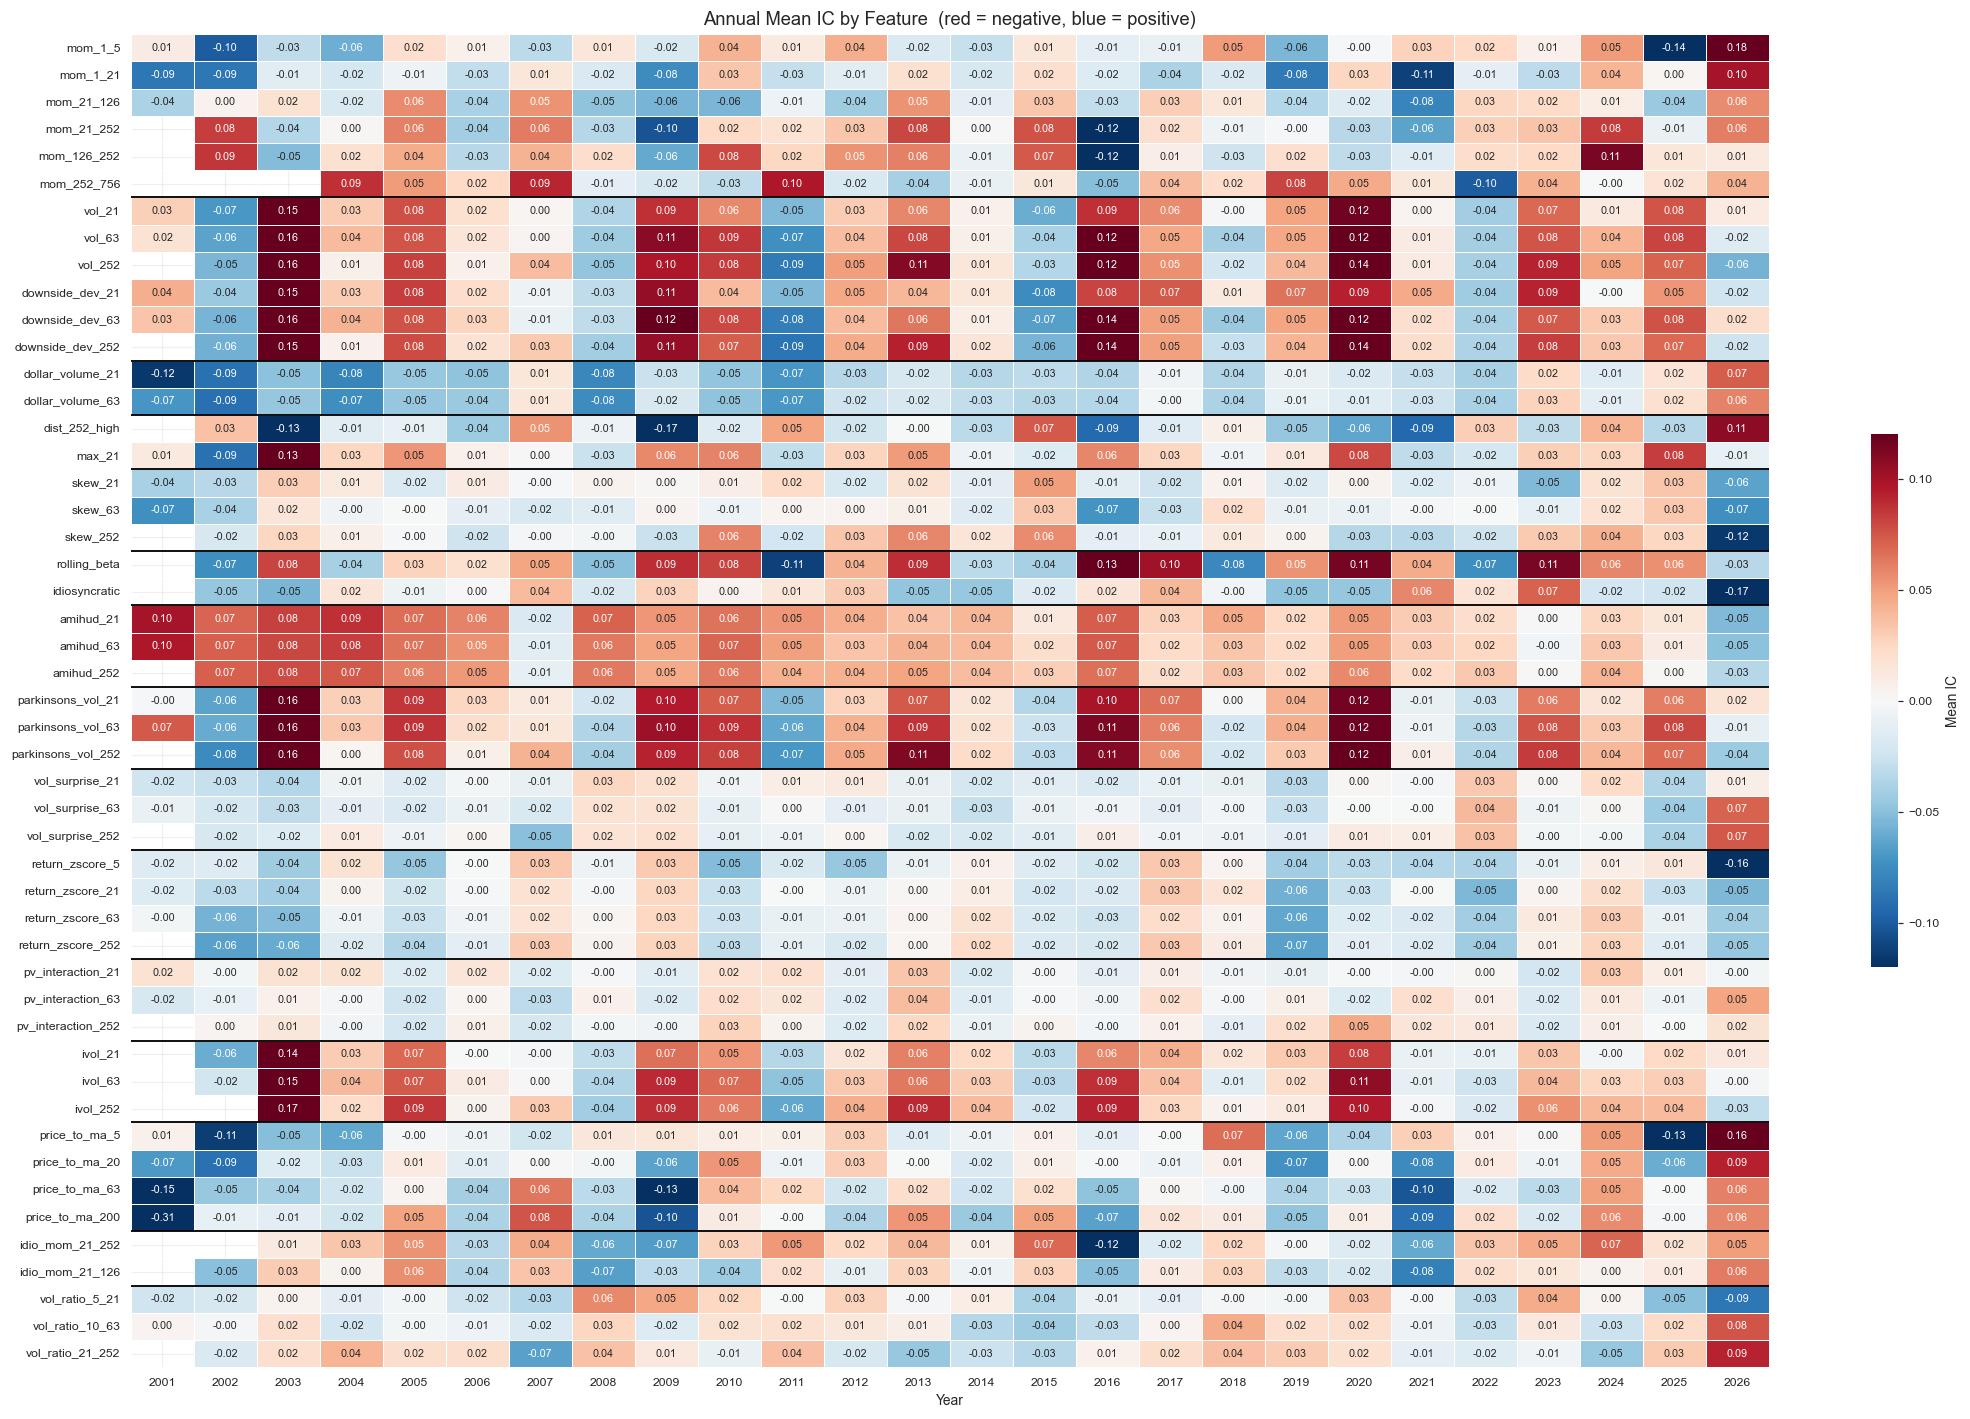

In [15]:
# ── Annual mean IC heatmap ─────────────────────────────────────────────────
annual_ic = ic_df.groupby(ic_df.index.year).mean().T

# Order rows by group
ordered_feats = [f for g in FEATURE_GROUPS for f in FEATURE_GROUPS[g] if f in annual_ic.index]
annual_ic = annual_ic.loc[ordered_feats]
abs_max = min(annual_ic.abs().quantile(0.95).max(), 0.12)

fig, ax = plt.subplots(figsize=(20, 13))
sns.heatmap(
    annual_ic, ax=ax, cmap="RdBu_r", center=0,
    vmin=-abs_max, vmax=abs_max,
    linewidths=0.4, linecolor="white",
    annot=True, fmt=".2f", annot_kws={"size": 7},
    cbar_kws={"label": "Mean IC", "shrink": 0.4},
)
ax.set_title("Annual Mean IC by Feature  (red = negative, blue = positive)")
ax.set_xlabel("Year")

# Group separator lines
group_sizes = [len(FEATURE_GROUPS[g]) for g in FEATURE_GROUPS]
boundaries  = list(np.cumsum(group_sizes)[:-1])
for b in boundaries:
    ax.axhline(b, color="black", lw=1.2)

plt.tight_layout()
plt.savefig(SAVE_DIR / "ic_annual_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

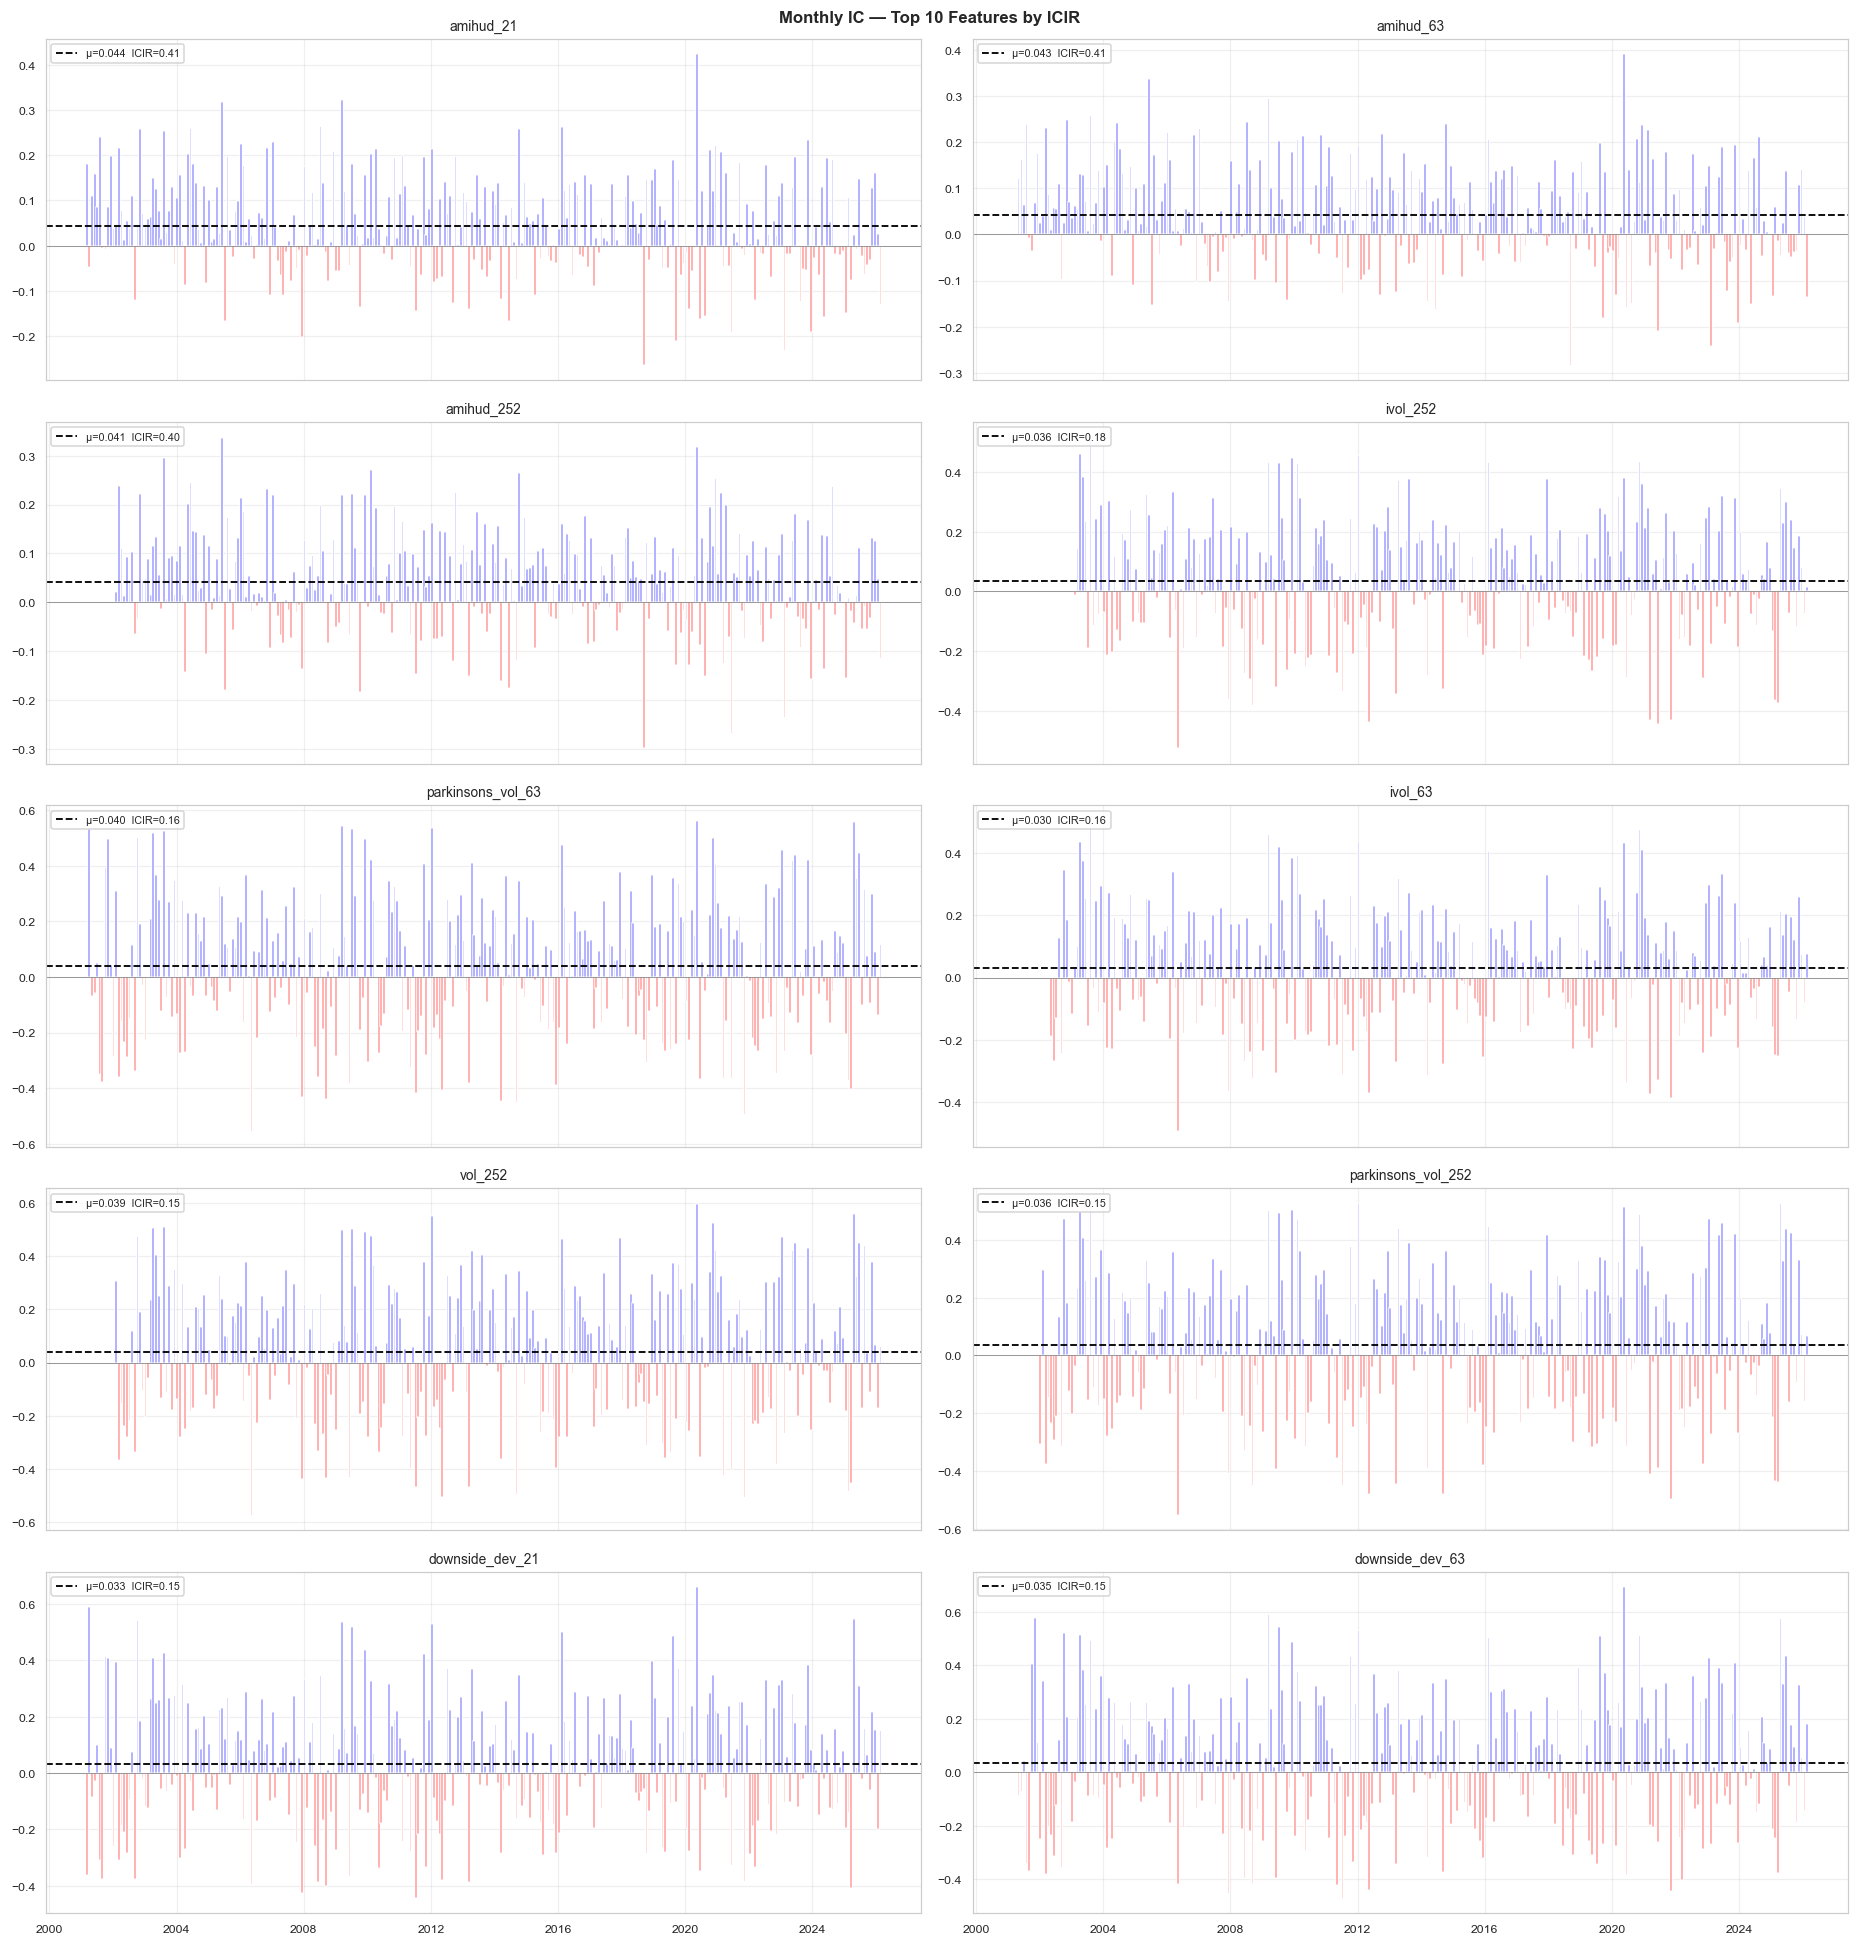

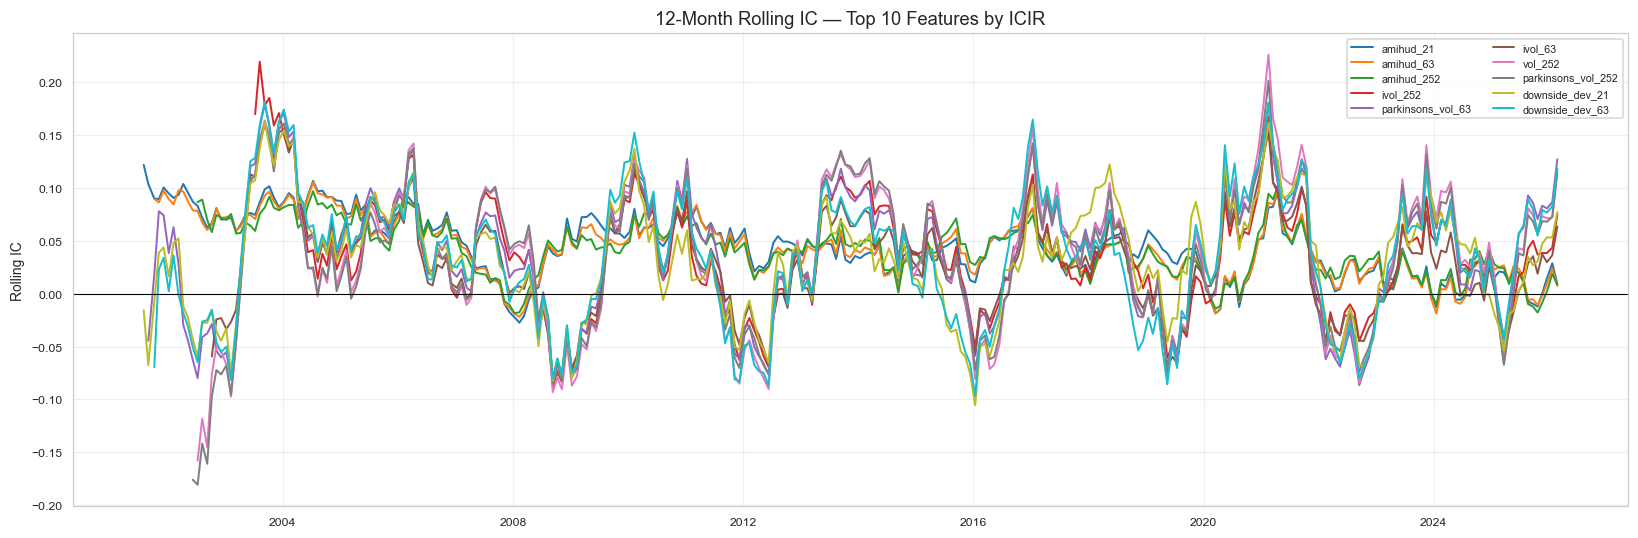

In [16]:
# ── Monthly IC bar charts for top 10 features by |ICIR| ────────────────────
top10 = ic_stats.head(10).index.tolist()   # already sorted by ICIR desc

fig, axes = plt.subplots(5, 2, figsize=(17, 18), sharex=True)
axes = axes.flatten()
for i, feat in enumerate(top10):
    ax = axes[i]
    ic_s = ic_df[feat].dropna()
    bar_c = ["blue" if v >= 0 else "red" for v in ic_s]
    ax.bar(ic_s.index, ic_s.values, color=bar_c, width=20, alpha=0.85)
    ax.axhline(ic_s.mean(), color="black", ls="--", lw=1.2,
               label=f"μ={ic_s.mean():.3f}  ICIR={ic_stats.loc[feat,'icir']:.2f}")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7, loc="upper left")
fig.suptitle("Monthly IC — Top 10 Features by ICIR", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "ic_monthly_top10.png", dpi=130, bbox_inches="tight")
plt.show()

# ── 12-month rolling IC for top 10 ──────────────────────────────────────
rolling_ic = ic_df[top10].rolling(12, min_periods=6).mean()
fig, ax = plt.subplots(figsize=(15, 5))
for feat in top10:
    ax.plot(rolling_ic.index, rolling_ic[feat], lw=1.3, label=feat, alpha=1)
ax.axhline(0, color="black", lw=0.7)
ax.set_title("12-Month Rolling IC — Top 10 Features by ICIR")
ax.set_ylabel("Rolling IC")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(SAVE_DIR / "ic_rolling_top10.png", dpi=130, bbox_inches="tight")
plt.show()

---
## 7. IC Stability Across Market Regimes

We split the sample into three sub-periods to check whether signal strength is consistent
or concentrated in a single era.


=== Mean IC by market regime ===
_period             pre-2010  2010-2019     2020+
amihud_21           0.062904   0.041994  0.021984
amihud_252          0.054200   0.040773  0.024378
amihud_63           0.059646   0.040612  0.021558
parkinsons_vol_63   0.043546   0.034279  0.042737
parkinsons_vol_252  0.032527   0.033730  0.045224
vol_252             0.036149   0.033390  0.050034
parkinsons_vol_21   0.035751   0.030926  0.035860
ivol_252            0.050120   0.028327  0.032924
downside_dev_252    0.037691   0.028090  0.049056
vol_63              0.034694   0.027385  0.046822
ivol_63             0.040666   0.024390  0.026691
downside_dev_21     0.038865   0.024150  0.038306
ivol_21             0.028451   0.023508  0.019487
rolling_beta        0.013422   0.023160  0.049630
vol_21              0.032051   0.023120  0.038093
downside_dev_63     0.041517   0.023048  0.046584
skew_252           -0.005519   0.019596 -0.001838
max_21              0.018565   0.017551  0.026540
mom_126_252      

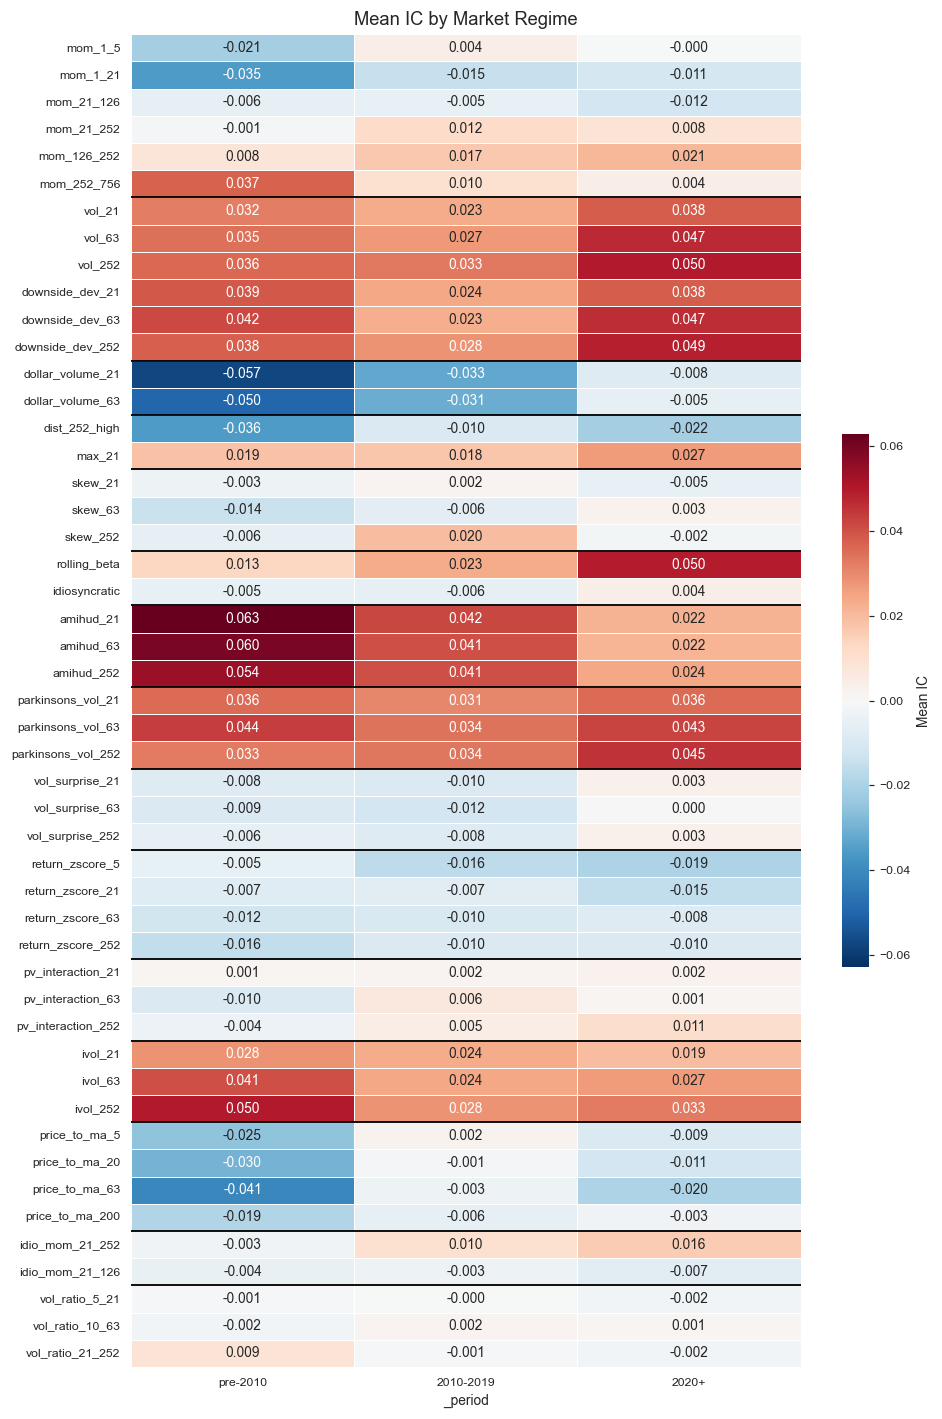

In [17]:
def period_label(d):
    y = d.year
    if y < 2010:
        return "pre-2010"
    elif y < 2020:
        return "2010-2019"
    else:
        return "2020+"

period_series = ic_df.index.map(period_label)
ic_by_period  = ic_df.copy()
ic_by_period["_period"] = period_series
ic_by_period  = ic_by_period.groupby("_period")[ALL_FEATURES].mean()

# Order period rows
period_order = ["pre-2010", "2010-2019", "2020+"]
ic_by_period = ic_by_period.reindex(period_order)

print("=== Mean IC by market regime ===")
print(ic_by_period.T.sort_values("2010-2019", ascending=False).to_string())

# Heatmap
ic_period_T = ic_by_period.T.loc[ordered_feats]
abs_max_p = min(ic_period_T.abs().max().max(), 0.15)

fig, ax = plt.subplots(figsize=(9, 13))
sns.heatmap(
    ic_period_T, ax=ax, cmap="RdBu_r", center=0,
    vmin=-abs_max_p, vmax=abs_max_p,
    linewidths=0.5, linecolor="white",
    annot=True, fmt=".3f", annot_kws={"size": 9},
    cbar_kws={"label": "Mean IC", "shrink": 0.4},
)
for b in boundaries:
    ax.axhline(b, color="black", lw=1.2)
ax.set_title("Mean IC by Market Regime")
plt.tight_layout()
plt.savefig(SAVE_DIR / "ic_by_regime.png", dpi=130, bbox_inches="tight")
plt.show()

---
## 8. Quintile Spread Analysis

For the top 8 features by ICIR we sort stocks into quintiles on each cross-section
and compute the average forward-return rank per bucket, then average across dates.

A monotonic Q1 → Q5 profile confirms that IC is not driven by outliers.
Monotonicity ρ is the Spearman correlation between quintile rank (1–5) and mean return.


In [26]:
top8 = ic_stats.head(8).index.tolist()
N_Q  = 10

def compute_quintile_profile(feat_col, panel=panel_sampled, n_q=N_Q):
    rows = []
    for _, g in panel.groupby(level="Date"):
        # g is the cross-section for a single date - a snapshot of all the stocks and features
        g = g[[feat_col, "target"]].dropna()
        if len(g) < n_q * 5:
            continue
        try:
            ql = pd.qcut(g[feat_col], n_q, labels=range(1, n_q + 1), duplicates="drop")

        except ValueError:
            continue
        if ql.nunique() < n_q:
            continue
        rows.append(g.groupby(ql)["target"].mean())
    if not rows:
        return pd.Series(np.nan, index=[f"Q{i}" for i in range(1, n_q + 1)])
    df_q = pd.DataFrame(rows)
    mean_q = df_q.mean()
    mean_q.index = [f"Q{int(i)}" for i in mean_q.index]
    return mean_q

print("Computing quintile profiles for top 8 features ...")
quintile_profiles = {f: compute_quintile_profile(f) for f in tqdm(top8)}

Computing quintile profiles for top 8 features ...


  0%|          | 0/8 [00:00<?, ?it/s]

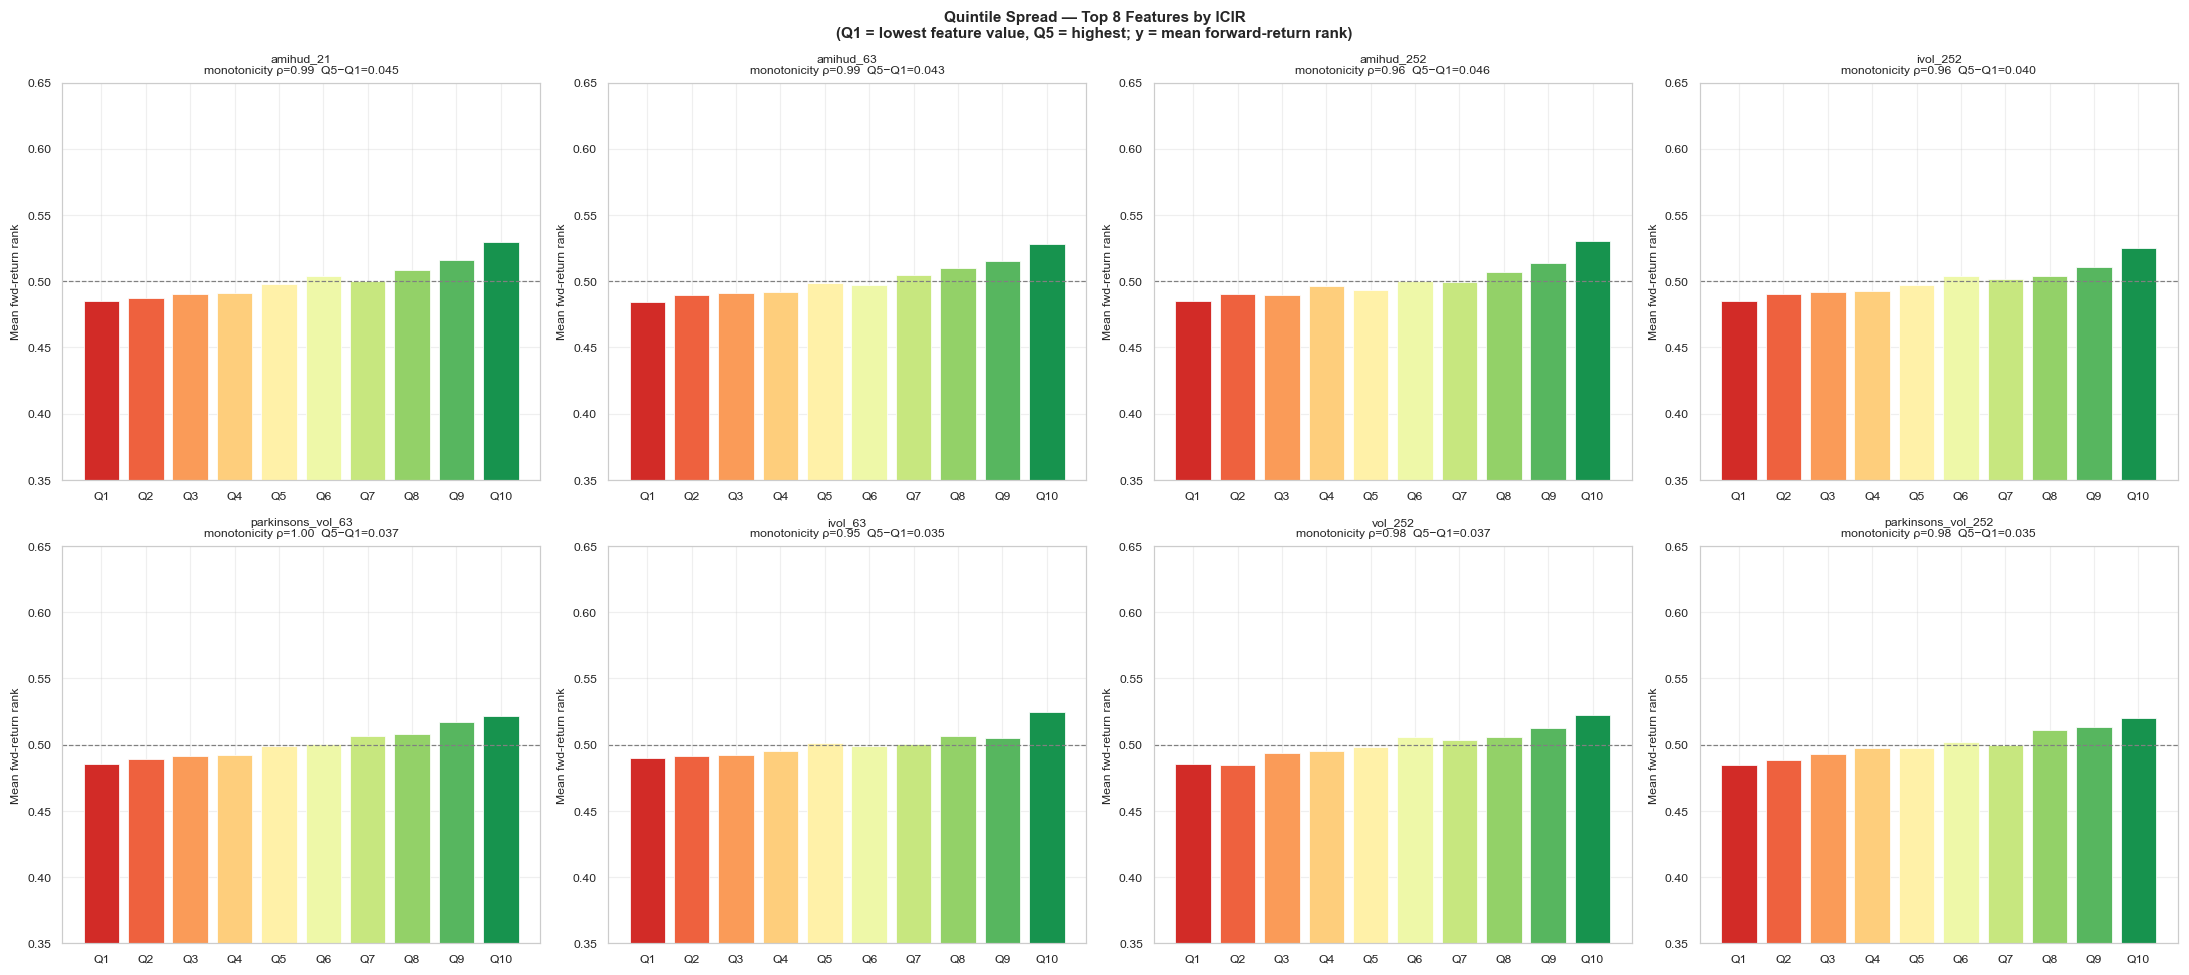

In [27]:
ncols = 4
nrows = (len(top8) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

for idx, feat in enumerate(top8):
    ax  = axes[idx // ncols][idx % ncols]
    qp  = quintile_profiles[feat]
    if qp.isna().all():
        ax.text(0.5, 0.5, "insufficient data", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(feat, fontsize=9)
        continue

    q_palette = sns.color_palette("RdYlGn", n_colors=len(qp))
    ax.bar(qp.index, qp.values, color=q_palette, edgecolor="white", lw=0.5)
    ax.axhline(0.5, color="gray", ls="--", lw=0.8)

    xs = np.arange(1, len(qp) + 1)
    mono_rho, _ = stats.spearmanr(xs, qp.values)
    q1_q5_spread = qp.iloc[-1] - qp.iloc[0] if len(qp) >= 2 else np.nan
    ax.set_title(
        f"{feat}\nmonotonicity ρ={mono_rho:.2f}  Q5−Q1={q1_q5_spread:.3f}",
        fontsize=8,
    )
    ax.set_ylabel("Mean fwd-return rank", fontsize=8)
    ax.set_ylim(0.35, 0.65)

for idx in range(len(top8), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle(
    "Quintile Spread — Top 8 Features by ICIR\n"
    "(Q1 = lowest feature value, Q5 = highest; y = mean forward-return rank)",
    fontsize=10, fontweight="bold",
)
plt.tight_layout()
plt.savefig(SAVE_DIR / "quintile_spreads.png", dpi=130, bbox_inches="tight")
plt.show()

In [36]:
bottom6 = ic_stats.tail(6).index.tolist()
N_Q  = 5
print("Computing quintile profiles for top 8 features ...")
quintile_profiles_bottom = {f: compute_quintile_profile(f, n_q = N_Q) for f in tqdm(bottom6)}

Computing quintile profiles for top 8 features ...


  0%|          | 0/6 [00:00<?, ?it/s]

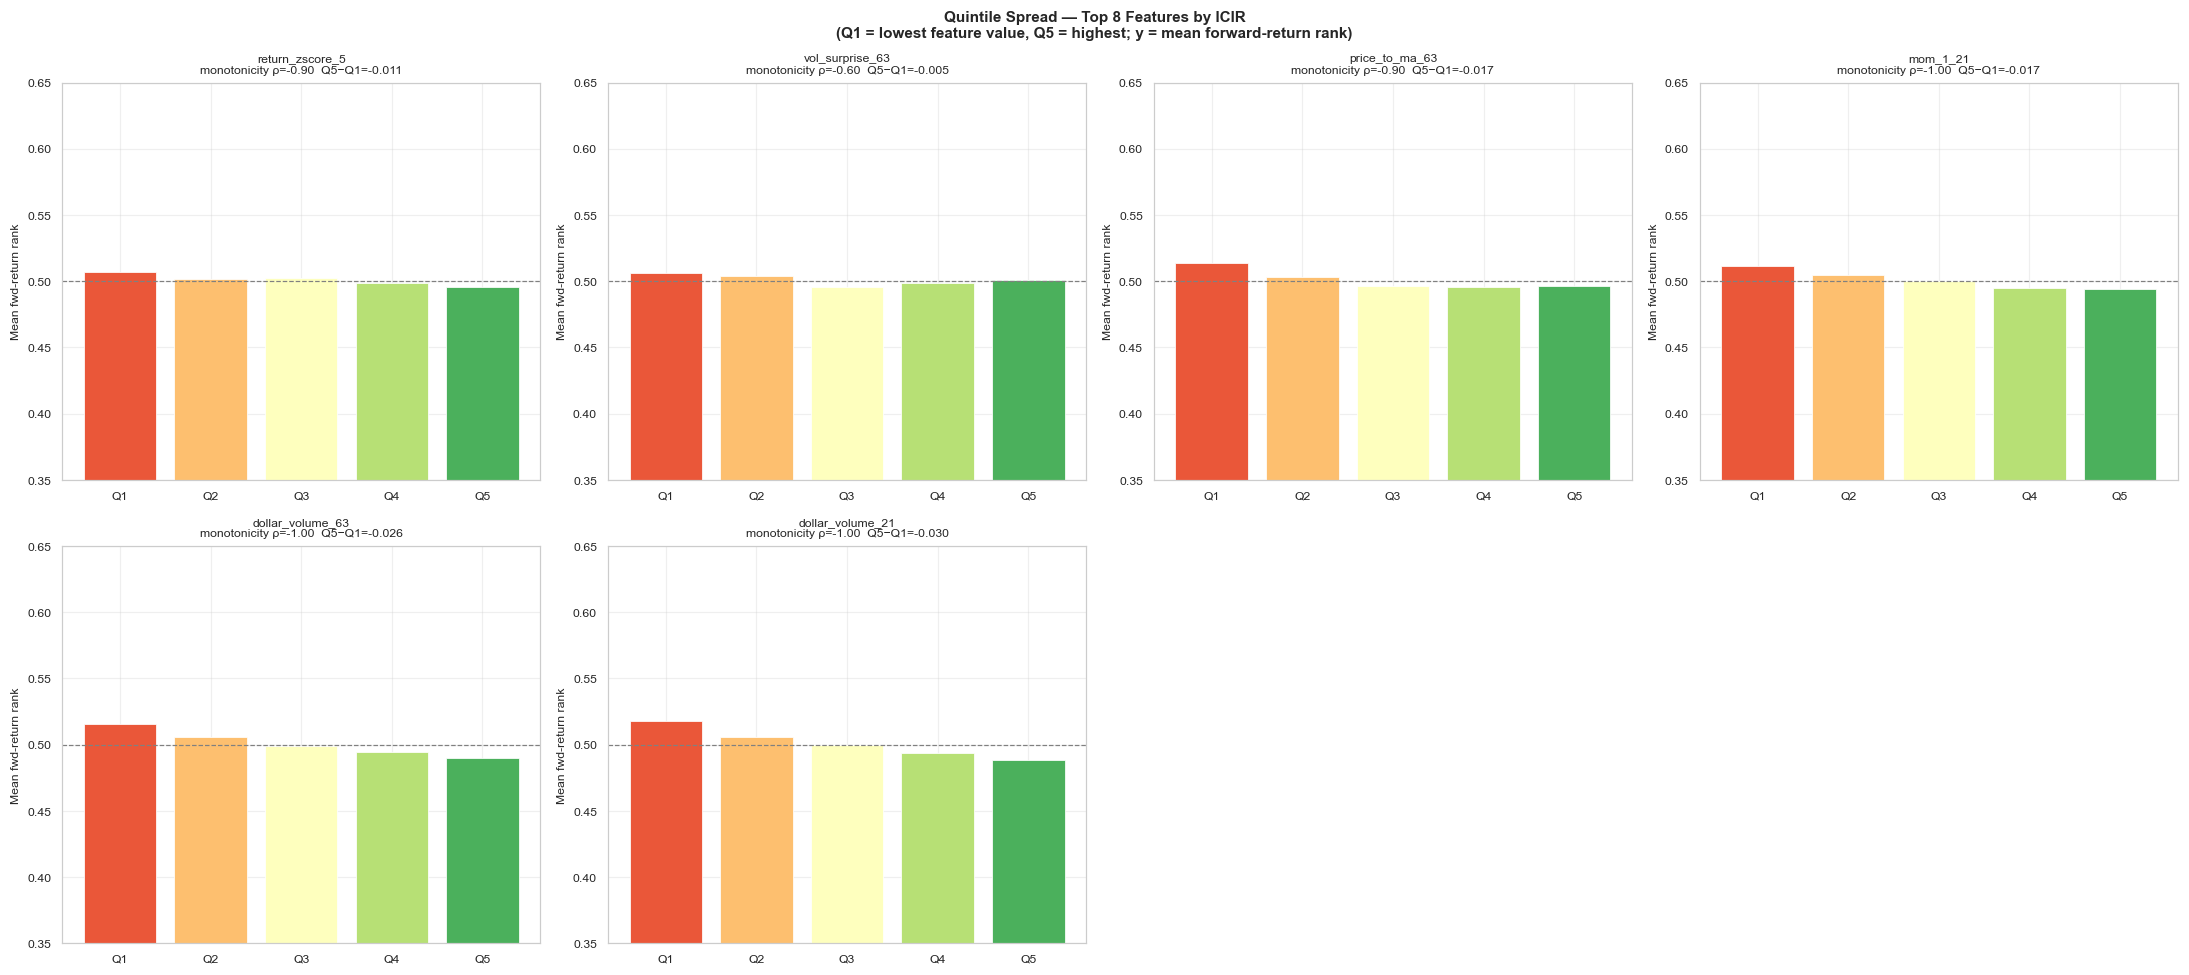

In [37]:
ncols = 4
nrows = (len(bottom6) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

for idx, feat in enumerate(bottom6):
    ax  = axes[idx // ncols][idx % ncols]
    qp  = quintile_profiles_bottom[feat]
    if qp.isna().all():
        ax.text(0.5, 0.5, "insufficient data", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(feat, fontsize=9)
        continue

    q_palette = sns.color_palette("RdYlGn", n_colors=len(qp))
    ax.bar(qp.index, qp.values, color=q_palette, edgecolor="white", lw=0.5)
    ax.axhline(0.5, color="gray", ls="--", lw=0.8)

    xs = np.arange(1, len(qp) + 1)
    mono_rho, _ = stats.spearmanr(xs, qp.values)
    q1_q5_spread = qp.iloc[-1] - qp.iloc[0] if len(qp) >= 2 else np.nan
    ax.set_title(
        f"{feat}\nmonotonicity ρ={mono_rho:.2f}  Q5−Q1={q1_q5_spread:.3f}",
        fontsize=8,
    )
    ax.set_ylabel("Mean fwd-return rank", fontsize=8)
    ax.set_ylim(0.35, 0.65)

for idx in range(len(bottom6), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle(
    "Quintile Spread — Top 8 Features by ICIR\n"
    "(Q1 = lowest feature value, Q5 = highest; y = mean forward-return rank)",
    fontsize=10, fontweight="bold",
)
plt.tight_layout()
plt.savefig(SAVE_DIR / "quintile_spreads_bottom.png", dpi=130, bbox_inches="tight")
plt.show()

---
## 9. Final Summary Table

In [38]:
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", "{:.4f}".format)

summary = (
    ic_stats[["group","mean_ic","ic_std","icir","nw_tstat","nw_pval","hit_rate","sig"]]
    .sort_values("icir", ascending=False)
    .reset_index()
    .rename(columns={"index": "feature"})
)
summary.insert(0, "rank", range(1, len(summary) + 1))
summary.to_csv(SAVE_DIR / "ic_summary_ranked.csv", index=False)

# Styled display
def highlight_sig(row):
    if row["sig"] == "**":
        return ["background-color: #c6efce"] * len(row)
    elif row["sig"] == "*":
        return ["background-color: #ffeb9c"] * len(row)
    elif row["mean_ic"] < 0 and row["nw_pval"] < 0.05:
        return ["background-color: #ffc7ce"] * len(row)
    return [""] * len(row)

display(
    summary.set_index("rank")
    .style
    .apply(highlight_sig, axis=1)
    .format({"mean_ic": "{:.4f}", "ic_std": "{:.4f}", "icir": "{:.3f}",
             "nw_tstat": "{:.2f}", "nw_pval": "{:.4f}", "hit_rate": "{:.1%}"})
)
print(f"\nSaved → {SAVE_DIR / 'ic_summary_ranked.csv'}")

,feature,group,mean_ic,ic_std,icir,nw_tstat,nw_pval,hit_rate,sig
rank,,,,,,,,,
1,amihud_21,amihud,0.0444,0.1073,0.414,8.11,0.0000,66.0%,**
2,amihud_63,amihud,0.0425,0.1048,0.406,7.95,0.0000,67.4%,**
3,amihud_252,amihud,0.0410,0.1032,0.397,7.73,0.0000,66.4%,**
4,ivol_252,ivol,0.0361,0.1995,0.181,3.23,0.0014,58.5%,**
5,parkinsons_vol_63,parkinson_vol,0.0396,0.2410,0.164,3.16,0.0017,56.9%,**
6,ivol_63,ivol,0.0302,0.1858,0.163,2.94,0.0036,57.3%,**
7,vol_252,volatility,0.0386,0.2529,0.152,2.76,0.0062,56.7%,**
8,parkinsons_vol_252,parkinson_vol,0.0363,0.2425,0.150,2.73,0.0067,57.2%,**
9,downside_dev_21,volatility,0.0328,0.2189,0.150,2.96,0.0034,55.0%,**



Saved → ../../results/feature_exploration/ic_summary_ranked.csv
